# Uranium-235 Fissions under Variable Boric Acid Concentrations and Lowly-Enriched Uranium Number Densities in a Water-Coolant Environment

**Semester**: Winter 2025

**Name:** Rhea Zhu

# Table of Contents

<summary><strong>Uranium-235 Fissions under Variable Boric Acid Concentrations and Lowly-Enriched Uranium Number Densities in a Water-Coolant Environment</strong></summary> 


- [1. Project Overview](#overview) <br>
    - [1.1 Introduction](#introduction)<br>
        - [1.1.1 What is Nuclear Fission?](#what-is-nuclear-fission)<br>
        - [1.1.2 What is Boron Absorption](#what-is-boron-absorption-why-is-it-useful)<br>
        - [1.1.3 Mean Free Path](#mean-free-path) <br>
        - [1.1.4 How is a Nuclear Reactor Structured?](#how-is-a-nuclear-reactor-structuredh) <br>
        - [1.1.5 Chemical Species in Water Coolant Environments](#chemical-species-in-water-coolant-environments) <br>
    - [1.2 Experimental Method & Analysis](#experimental-method--analysis)<br> 
        - [1.2.1 Simulation Setup](#simulation-setup)<br> 
        - [1.2.2 Physical Assumptions](#physical-assumptions)<br> 
        - [1.2.3 Analysis Method](#analysis-method)<br> 
        - [1.2.4 Programmed Code for Simulations](#programmed-code-for-simulations)  <br> 
- [2. Analysis: Investigating Combinations of Boric Acid Concentration and Lowly-Enriched Uranium Number Density ](#analysis-investigating-combinations-of-boric-acid-concentration-and-lowly-enriched-uranium-number-density) <br> 
    - [2.1 Part I: Preliminary Trials](#part-i-preliminary-trials-to-understand--factor-and-species-interaction-counts)<br>  
    - [2.2 Part II: Quantitative Phase Space Analysis](#2-preliminary-trials-with-wind)<br>  
- [3. Quantiative Phase Space Analysis](#quantitative-phase-space-analysis)
    - [3.1 Step One: Phase Space of Drag Coefficients and Surface Area to Create Safe Landings](#step-1-phase-space-of-drag-coefficients-and-surface-area-to-create-safe-landings)<br> 
    - [3.2 Step Two: Range of Parameters Creating a Successful Rocket Recovery](#step-2-range-of-parameters-creating-a-successful-rocket-recovery)<br> 
    - [3.3 Quantitative Phase Space Analysis](#quantitative-phase-space-analysis) <br> 
- [4. Results and Discussion](#results--discussion) <br> 
    - [4.1 Part I General Analysis](#part-i-general-analysis)<br> 
    - [4.2 Part II General Analysis](#part-ii-general-analysis)<br> 
    - [4.3 Limitations & Next Steps](#limitations--next-steps)<br> 
- [5. Acknowledgments](#acknowledgements) 
- [6. References](#references) 
- [7. Appendix 1: Code Validation](#appendix-1-code-validation)

# Overview

This project employs the Monte Carlo algorithm to investigate the effects of U-235 number density and boron capture uranium-235 (U-235) in a water coolant fission experiment. To do this, we vary the number density of lowly-enriched uranium and the concentration of boric acid, observing two quantities. Firstly, we simulate the evolution of neutron multiplication factors $k$ over multiple generations. Then, we do the same thing with the distribution of neutron interactions in uranium, boron, hydrogen, and oxygen, with the latter two species considered due to the water environment in this experiment. We specifically explore the following research questions:

**Research Question**

1. **Boric Acid Concentration**: Given a specific concentrarion of boric acid, which contains stable Boron-10 neutron absorbers, how is the multiplication factor $k$ and the composition of the interacted chemical species in a U-235 fission experiment affected?  
2. **Uranium Number Density:** Given a specific number density of lowly enriched uranium, how is the multiplication factor $k$ and the composition of the interacted chemical species in a U-235 fission experiment affected? 
3. **2-D Phase Space**: How do these two parameters to overall affect multiplication factor and chemical composition? Specifically, what combinations of boric acid concentration and uranium number density lead to multiplication factors of 1 (within two decimals)? 

## Introduction 

### What is Nuclear Fission?
Nuclear fission is a process in which an unstable nucleus decays into two or more smaller nuclei, releasing energy in the form of heat. This occurs in a nuclear reactor as a chain reaction, where each smaller nucleus is “captured” by another unstable nucleus, causing the unstable nucleus to further decay into two smaller nuclei and generate significant amounts of heat. Nuclear fission is a very sustainable, reliable source of energy, and hence is used in various industrial sectors such as agriculture and electricity. [1] 

The chain reaction rate of a nuclear reactor is characterized by the multiplication factor $k$. Mathematically, we define $k$ as $$k = \frac{\text{\# of neutrons in generation (n+1)}}{\text{\# of neutrons in generation n}}$$ where a generation denotes one “round” of nucleic decays. We classify the multiplicative factor in three ways: 

1. **$k>1$**: When $k>1$, the nuclear reaction is supercritical and grows exponentially.
2. **$k = 1$**: When $k = 1$, the nuclear reaction is critical and self-sustaining. 
3. **$k < 1$**: When $k < 1$, the nuclear reaction is subcritical and dies out. [2]

This project focuses on the nuclear fission of Uranium-235 (or U-235), a fissile isotope of uranium. U-235 is found in extremely low concentrations (~0.72%) of natural uranium [3]. Due to this, uranium undergo a process where the Uranium-235 is lowly enriched, increasing its concentration to significant amounts. Lowly enriched uranium for power reactors typically contains 3-5% of Uranium-235 [3].


### What is Boron Absorption? Why is it useful?

In many cases, the natural fission rate of a nuclear reaction occurs too quickly, such that the energy produced can be difficult to contain; as a result, measures are often implemented to mitigate this potential hazard. One such method is boron absorption, in which boric acid is placed into the nuclear reactor to control fission rates. Boric acid contains the isotope Boron-10, a common, stable isotope. During a chain reaction, Boron-10 naturally absorbs a neutron to produce a lithium ion:  $$^{10}\mathrm{B} + n \rightarrow {}^{7}\mathrm{Li} + \alpha + \Delta$$
 This consumes the neutron, reducing the number of neutrons able to be produced in the next generation. [4]

**Microscopic cross section, $\sigma_a$** is the measure of the probability that a single atom will interact with a specific particle, such as a neutron; a higher cross section indicates a higher interaction probability. In a nuclear reaction, this quantity depends on the thermal energy of the incoming neutron, due to quantum mechanical effects involving the neutron’s wavefunction [5][6]. At 300K, the Maxwellian average (the central tendency of particle speeds in idealized gases [7]) of the microscopic cross section of Boron-10 is 3840 barns (which is $10^{-24} cm^2$), indicating excellent neutron absorption [8].

Naturally, a single atom can undergo many different processes with a neutron, and as a result have individual microscopic cross section for each. The microscopic cross section we are referring to above is the **total microscopic cross section**, which is the sum of all individual cross sections [9]. In other words, this is the measure probability that an atom will, in general, interact with boron. 

**Macroscopic cross section** “represents the effective target area of all of the nuclei contained in the volume of the material”; in other words, it is a measure of the combined probability that a neutron will interact with any boron atom in a nuclear reactor *per unit length*. Due to this, the formula for macroscopic absorption cross section, $\Sigma_a$, is $$\Sigma_a = N \times \sigma_a$$ where $N$ is the number density of boron atoms (with units $1/cm^3$) [10]. Then, the total probability of a neutron not absorbed by boron for a length $l$ is exponential [11]: $$P = e^{-\Sigma_a l}$$ Like microscopic cross section, there are individual macroscopic cross sections for each process associated with a species interacting with the neutron. [9]

Since cross sections denote the probability of neutrons interacting with certain atoms, we must consider not only the cross sections of boron-10 in this experiment, but of the other species in our nuclear reactor environment as well, primarily uranium-235, as well as the hydrogen and oxygen from our water coolant (explained in "Chemical Species in Water Coolant Environments"). 

### Mean Free Path

Now that we have considered each individual process a neutron through cross sections, how do we know when the neutron actually interacts with a chemical species in the environment? To quantify this, we use the **mean free path**, which the average distance a particle travels before colliding with another particle. This is calculated by taking the inverse of the total macroscopic cross sections of all possible processes combined: $$\lambda = \frac{1}{\sum (\sum_{\text{total macroscopic cross section of each species}})}$$ [19] We explain the processes relevant in this project in "Chemical Species in Water Coolant Environments".

### How is a Nuclear Reactor Structured? 

A nuclear reactor structure is has two main components: a core, and a pressure vessel. The core is the region of space where the U-235 nuclei undergo fission and a chain reaction; this is also where moderators such as Boron-10 are added to contain the rate of decay. The pressure vessel if a physical container that contains the core. When neutrons travel too far without colliding with another U-235 nucleus, neutrons can "leak" past the core and into the pressure vessel, effectively removing itself from the chain reaction [12][13].


### Chemical Species in Water Coolant Environments  

In nuclear reactors, coolants are often used to dissipate the heat generated in the core. One such coolant is water, due to its high specific heat capacity. [14]

As a result, in this project, we consider the processes below in this project. Note that $\Delta$ represents a release in energy.

**Uranium Processes** 

1. *Fission*: Uranium absorbs a neutron and produces 2 neutrons, along with its corresponding fission fragmenet barium and krypton $$^{235}\mathrm{U} + n \rightarrow {}^{144}\mathrm{Ba} + {}^{90}\mathrm{Kr} +2n + \Delta$$ 
2. *Radiative Capture*: Uranium can also absorb a neutron and not produce 2 neutrons, instead transforming into a heavier isotope U-236: $$^{235}\mathrm{U} + n \rightarrow {}^{236}\mathrm{U}$$
3. *Elastic Scattering*: Finally, it is possible for the neutron to collide with the uranium and simply be redirected in its direction without absorption, This is know as elastic scattering. [15][16]

**Boron-10 Processes**
1. *Absorption*: As detailed before, boron can absorbe a neutron in the process $$^{10}\mathrm{B} + n \rightarrow {}^{7}\mathrm{Li} + \alpha + \Delta$$ 
2. *Elastic Scattering*: It can also elastically scatter the neutron, similar to uranium. [8]

**Hydrogen and Oxygen Processes** 

Since water is a coolant in our environment, hydrogen and oxygen also plays a part in the interaction between the chemical species! The mainly elastically scatter neutrons, so we will only consider this process for the two atoms.[17][18] 

Each of these 7 processes (uranium fision, radiative capture, and elastic scattering; boron-10 absorption and elastic scattering; hydrogen elastic scattering; oxygen elastic scattering) have their own individual microscopic and hence macroscopic cross sections.


# Experimental Analysis & Programming 

In this project, I explore the effect on boric acid concentration, defined as $$\rho = \frac{\text{\# of boron atoms}}{\text{Volume of Nuclear Reactor}}$$ as well as lowly enriched uranium number density on two things: (1) the multiplication factor of Uranium-235, and (2) the frequency and type of species interactions with neutrons.

### Simulation Setup  

1. **Environment**: 250 neutron atoms are initially present in a cubic nuclear reactor with a side length of *10 \text{cm}* with a temperatur of 300K. Boric concentration and uranium number density is set.
2. **Neutron Travelling**: Each of neutrons travel in random direction at a variable distance $L$ defined by $$p(L) \propto e^{-L/\lambda} $$ where the mean free path is calculated given the formula above.
3. After travelling $L$, if the neutron is outside the bounds of the core (defined by a cube of side length 10cm), the neutron undergoes leakage and leaves the system. 
4. If not, the neutron interacts with one of four atoms: U-235, B-10, H, or O, in one of the seven preocesses. This is determined by the individual processes' macroscopic cross sections. 

**Process Possibilities** 

1. **Uranium Fission**: If the neutron undergoes uranium fission, the uranium nucleus absorbs the neutron and produces two new neutrons. These neutrons have a original position of incoming neutron and will travel onwards at a random direction. 
2. **Uranium Radiative Capture**: If the neutron undergoes radiative capture, the nucleus absorbs the neutron, functionally removing it out of the system. 
3. **Uranium Elastic Scattering**: If the neutron undergoes elastic scattering, it is carried over to the next generation and assigned a new random direction of travel. 
4. **Boron Absorption**: If the neutron undergoes boron-10 absorption, the neutron is removed from the system 

5.6.7. **Boron, Hydrogen, and Oxygen Elastic Scattering**: Same as uranium elastic scattering. 


This simulation runs for 5 generations and 50 replications. We chose to run the simultion for 5 generations after some initial runs, observing that multiplication factor generally stabilizes after 5 generations for different combinations of boric acid concentration and uranium number density. 

### Physical Assumptions
* **No Heating**: The heat generated by the nuclear processes does not affect the system
* **Uniform Distribution of Chemical Species**: All uranium, boron, hydrogen, and oxygen atoms are distributed evenly and randomly, and the movement of these species are not considered.
* **Limited Processes**: Only 7 of the most prominent processes for each atom is considered in this simulation.
* **Byproducts**: Byproducts do not interfere with system 

* **Microscopic Cross Section**: We take the microscopic cross section to be the same for each of the individual species, with its value taken from experimental studies. However, in real-world contexts, there exists a variability in cross section for each Boron-10 atom. 
* **Isolated System**: No forces or external energy is experimenced by the atoms inside the simulation, other than nuclear fission.


## Analysis Method
The analysis for this project will be separated into two portions:

1. **Preliminary Trials**: In this section, we manually alter boric acid concentration and uranium number density and observe its effects on multiplication factor and species interactions. We do this independently, first fixing boric acid concentration and then uranium number density.
2. **Quantitative Phase Space Analysis**: In this section, we quantitatively determine (1) the combinations of our two parameters where the multipication factor $k$ is one, to two decimal places. To do this, we run the ismulation of a wide number of combinations in our phase space, with the ranges determined based on initial trials. We do the same thing for the frequency of species interaction for each of the four atoms and observe its characteristics. In total, we executed 5 different phase space analyses: one for multiplication factor, and four for each of the four atoms.


## Programmed Code for Simulations
Below is the code used for this simulation. The code block summaries explains the logic behind each function.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random
import time


# CONSTANTS 

a = 10 #cm, side length of core region box

rho = 1 # g/cm^3
avo = 6.022e23 # avogadro's number

normalization = 1

# Water Constants 

# Hydrogen constants, taken 1-H-1

hmolarmass = 1.00784 #g/mol 
hratio = 2 * hmolarmass/18.015  

hmassdensity = hratio * rho #g/cm^3 

hnumberdensity = hmassdensity * avo/hmolarmass / normalization

htotal = 30.6e-24 # microscopic cross section total, cm^2 
helastic = htotal # microscopic cross section elastic, cm^2

helasticmacro = hnumberdensity * helastic

htotalmacro = hnumberdensity * htotal
hcount = 0

'''We approximate hydrogen to only scatter neutrons.''' 

# Oxygen constants 

omolarmass = 15.999 #g/mol

oratio = omolarmass/18.015 
omassdensity = oratio * rho #g/cm^3 

onumberdensity = omassdensity * avo/omolarmass / normalization 

ototal = 3.965e-24 # microscopic cross section total, cm^2
oelastic = ototal # microscopic cross section elastic, cm^2

oelasticmacro = onumberdensity * oelastic

ototalmacro = ototal * onumberdensity

'''We approximate oxygen to only scatter neutrons''' 

'We approximate oxygen to only scatter neutrons'

**Code Block Summary**. This code defines the constant used throughout the simulation, as well as the macroscopic cross sections and number density of oxygen and hydrogen. 

In [3]:
#=================== FIND MULTIPLICATION FACTORS ================

def run_simulation_once(ppm, unumberdensity, display):

    #===================== INITIAL SETUP ======================#
    ocount = 0
    hcount = 0

    # Boron constants 

    boron_massdensity = ppm  * 1e-6 * rho # mass density of boron, g/cm^3
    boron_molarmass = 0.010811 #g/mol
    boron_numberdensity = boron_massdensity * avo/boron_molarmass 

    b10numberdensity = 0.2 * boron_numberdensity / normalization # number density of boron 10, #/m^3 

    b10elasticcross = 3837e-24 # microscopic absorption cross section, cm^2
    b10total = 3940e-24 # microscopic cross section total, cm^2
    b10scattercross = b10total - b10elasticcross # microscopic scatter cross section, cm^2 || approximated this simulation to be elastic & no other reactions

    b10absmacro = b10numberdensity * b10elasticcross 
    b10scattermacro = b10numberdensity * b10scattercross 

    b10totalmacro = b10numberdensity * b10total # total macroscopic cross section 
    bcount = 0

    '''We approximate b10 to only have an absorption and elastic scattering cross section'''

    # U-235 constants 

    u235numberdensity = unumberdensity*0.03 / normalization # USE THE INPUT PARAMETER


    u235fissioncross = 585.1e-24 # microscopic fission cross section, cm^2
    u235gammacross = 98.71e-24 # microscopic gamma cross section, cm^2
    u235total = 698.9e-24 # microscopic cross section total, cm^2
    u235elastic = u235total - u235fissioncross - u235gammacross # microscopic cross section elastic, cm^3 

    u235fissionmacro = u235numberdensity * u235fissioncross 
    u235gammamacro = u235numberdensity * u235gammacross 
    u235elasticmacro = u235numberdensity * u235elastic 

    u235totalmacro = u235numberdensity * u235total
    ucount = 0

    '''We approximate u235 to have only three cross sections: fission, gamma, and elastic scattering. We approximate the elastic scattering by taking the difference between total cross section and the sum of fission and gamma cross section''' 


    uraniums = int(u235numberdensity * a**3)
    borons = int(b10numberdensity * a**3) 

    #=================== PRINT TOTAL MACROSCOPIC CROSS SECTIONS 
    if display == "Yes":
        print("\n ")
        print("==================TOTAL MACROSCOPIC CROSS SECTIONS OF EACH SPECIES===================\n ")
        print(f"* Uranium-235: {u235totalmacro:7.2g}") 
        print(f"* Boron-10:    {b10totalmacro:7.2g}") 
        print(f"* Hydrogen:    {htotalmacro:7.2g}") 
        print(f"* Oxygen:      {ototalmacro:7.2g} \n")


    # Mean free path  
    totalmacro = u235totalmacro + b10totalmacro + htotalmacro + ototalmacro
    mean_free_path = 1/(totalmacro)

    if display == "Yes":
        print(f" THE STARTING MEAN FREE PATH IS {mean_free_path: 0.2e} cm \n") 



    gen = 5

    #================= SIMULATION =================## 
    previouspositions = [] # RESET for each replication
    newpositions = [] # RESET for each replication
    genneutrons = 250
    mean_free_paths = []

    k01 = 0
    k12 = 0 
    k23 = 0 
    k34 = 0
    k45 = 0

    for g in range(gen): #for each generation 
        neutrons = 0  

        for n in range(genneutrons): 

            if g == 0:  
                x0 = np.random.uniform(0, a) # get random x,y,z position within the cube
                y0 = np.random.uniform(0, a) # get random x,y,z position within the cube
                z0 = np.random.uniform(0, a) # get random x,y,z position within the cube
            else:
                x0 = previouspositions[n][0] # get x,y,z position of neutron from previous generation
                y0 = previouspositions[n][1] # get x,y,z position of neutron from previous generation
                z0 = previouspositions[n][2] # get x,y,z position of neutron from previous generation
            
            # Determine random direction and distance L travelled by neutron
            phi = np.random.uniform(0, 2 * np.pi)
            costheta = np.random.uniform(-1, 1)
            theta = np.arccos(costheta)
            L = -mean_free_path * np.log(np.random.uniform(0, 1))
            mean_free_paths.append(mean_free_path)

            # Determine the new position of the neutron IF it is NOT captured by boron or LEAKOUT out of the core
            x1 = x0 + L * np.sin(theta) * np.cos(phi)
            y1 = y0 + L * np.sin(theta) * np.sin(phi)
            z1 = z0 + L * np.cos(theta) 

            #===================== NUCLEAR REACTION POSSIBILITIES ====================

            # QUESTION 1. Is there leakage?

            if x1 < 0 or x1 > a or y1 < 0 or y1 > a or z1 < 0 or z1 > a:
                # Neutron leaks out of core, do not add to newpositions
                continue # Move to next neutron 

            # QUESTION 2. What atom does the neutron collide with? 
            rand = random.uniform(0,1) 
            random2 = random.uniform(0,1)

            if rand < u235totalmacro/totalmacro: 
                #choice = "Uranium"  
                ucount += 1

                if random2 < u235gammamacro/u235totalmacro: 
                    #reaction = "Gamma" 
                    u235numberdensity = uraniums/a**3 / normalization

                    continue
                elif random2 < (u235gammamacro + u235fissionmacro)/u235totalmacro:
                    uraniums -= 1 
                    u235numberdensity = uraniums/a**3 / normalization
                    #reaction = "Fission" 
                    for i in range(2):
                        newpositions.append([x1, y1, z1])
                        neutrons += 1 # Update number of neutrons produced in this generation
                else: 
                    #reaction = "Elastic"

                    newpositions.append([x1,y1,z1]) 
                    neutrons += 1
            
            elif u235totalmacro/totalmacro <= rand < (u235totalmacro+b10totalmacro)/totalmacro:
                bcount += 1
                #choice = "Boron" 

                if random2 < b10absmacro/b10totalmacro: 
                    #reaction = "Absorption"  
                    borons -= 1 
                    b10numberdensity = borons/a**3 / normalization

                    continue
                else: 
                    #reaction = "Elastic"   

                    newpositions.append([x1,y1,z1]) 
                    neutrons += 1

            elif (u235totalmacro+b10totalmacro)/totalmacro <= rand < (u235totalmacro+b10totalmacro + htotalmacro)/totalmacro:
                #choice = "Hydrogen"
                #reaction = "Elastic" 
                hcount += 1
                newpositions.append([x1,y1,z1]) 
                neutrons += 1
            else: 
                #choice = "Oxygen" 
                #reaction = "Elatic" 
                ocount += 1 
                newpositions.append([x1,y1,z1]) 
                neutrons += 1


            b10totalmacro = b10numberdensity * b10total
            b10absmacro = b10numberdensity * b10elasticcross 
            b10scattermacro = b10numberdensity * b10scattercross  # updating new macroscopic cross section

            u235fissionmacro = u235numberdensity * u235fissioncross 
            u235gammamacro = u235numberdensity * u235gammacross 
            u235elasticmacro = u235numberdensity * u235elastic 
            u235totalmacro = u235numberdensity * u235total

            totalmacro = u235totalmacro + b10totalmacro + htotalmacro + ototalmacro
            mean_free_path = 1/(totalmacro) 
            
        
        previouspositions = newpositions.copy() # Update previouspositions for next generation
        newpositions = [] # Reset newpositions for next generation
        Nbefore = genneutrons # Number of neutrons before this generation
        Nafter = neutrons # Number of neutrons after this generation

        # Calculate multiplication factor for this generation
        
        if g == 0: 
            #print(f" Generation {g} to {g+1}: Nafter = {Nafter}, Nbefore = {Nbefore}")
            k01 = Nafter/Nbefore if Nbefore > 0 else 0
        elif g == 1: 
            #print(f" Generation {g} to {g+1}: Nafter = {Nafter}, Nbefore = {Nbefore}")
            k12 = Nafter/Nbefore if Nbefore > 0 else 0
        elif g == 2: 
            #print(f" Generation {g} to {g+1}: Nafter = {Nafter}, Nbefore = {Nbefore}")
            k23 = Nafter/Nbefore if Nbefore > 0 else 0 
        elif g == 3: 
            #print(f" Generation {g} to {g+1}: Nafter = {Nafter}, Nbefore = {Nbefore}")
            k34 = Nafter/Nbefore if Nbefore > 0 else 0 
        elif g == 4: 
            #print(f" Generation {g} to {g+1}: Nafter = {Nafter}, Nbefore = {Nbefore}")
            k45 = Nafter/Nbefore if Nbefore > 0 else 0 
        genneutrons = neutrons 

        if Nafter == 0: 
            break
    
    return k01,k12,k23, k34, k45, ucount, bcount, ocount, hcount, mean_free_paths

**Code Block Summary**. This function runs the simulation once. It first calculates the initial cross sections and number density of boron and uranium. Then, for each generation, a loop is run for each of the surviving neutrons in that generation. A distance $L$ is generated based on the calculated mean free path, and random probabilities are used to determine which process each neutron undergoes. The number densities, macroscopic cross sections, and mean free path is updated accordingly per loop, and the multiplication factors are calculated for each generation. The counts of how many neutrons has interacted with each of the four atoms is also monitored and returned.

In [4]:
def analyze_multiplicationfactors(k01, k12, k23, k34, k45):

    # Calculate means
    k01mean = np.mean(k01)
    k12mean = np.mean(k12)
    k23mean = np.mean(k23)
    k34mean = np.mean(k34)
    k45mean = np.mean(k45) 

    # Create list of means
    means = [k01mean, k12mean, k23mean, k34mean, k45mean]

    # Calculate standard deviations
    k01std = np.std(k01)
    k12std = np.std(k12)
    k23std = np.std(k23)
    k34std = np.std(k34)
    k45std = np.std(k45) 

    # Create list of standard deviations
    stds = [k01std, k12std, k23std, k34std, k45std] 

    return means, stds


**Code Block Summary**. This function analyzes the multiplication factors for each generation, returning the means and standard deviations for each one.

In [5]:
def analyze_counts(ucount, ocount, bcount, hcount):

    # Calculate means
    umean = np.mean(ucount)
    omean = np.mean(ocount)
    bmean = np.mean(bcount)
    hmean = np.mean(hcount)

    # Create list of means
    means = [umean, omean, bmean, hmean]

    # Calculate standard deviations
    ustd = np.std(ucount)
    ostd = np.std(ocount)
    bstd = np.std(bcount)
    hstd = np.std(hcount) 

    # Create list of standard deviations
    stds = [ustd, ostd, bstd, hstd] 

    return means, stds

**Code Block Summary** This function analyzes the number of times a neutron interacts with each of the four atoms. Similar to the revious function, it returns the means and standard deviations.

In [6]:
def run_simulation_multiple(boronconc, unumdensity, r): 
    k1 = np.zeros(r)
    k2 = np.zeros(r)
    k3 = np.zeros(r)
    k4 = np.zeros(r)
    k5 = np.zeros(r)

    ucount = np.zeros(r)
    ocount = np.zeros(r)
    bcount = np.zeros(r)
    hcount = np.zeros(r)

    for i in range(r): 
        if i == 0: 
            k1[i], k2[i], k3[i], k4[i], k5[i], ucount[i], bcount[i], ocount[i], hcount[i], mean_free_paths = run_simulation_once(boronconc, unumdensity, "Yes") 
        else:
            k1[i], k2[i], k3[i], k4[i], k5[i], ucount[i], bcount[i], ocount[i], hcount[i], mean_free_paths = run_simulation_once(boronconc, unumdensity, "No") 


    means, stds = analyze_multiplicationfactors(k1,k2,k3,k4,k5)
    means1, stds1 = analyze_counts(ucount, ocount, bcount, hcount)

    print("================= SIMULATION RESULTS ================ \n")
    for i in range(5):
        print(f" Gen {i} to {i+1} || k : {means[i]:.3f} || std: {stds[i]:.1g} \n")  
    print(f"AVERAGE k VALUE ACROSS ALL GENERATIONS: {np.mean(means): 0.3f} || std: {np.std(means): 0.1g} \n") 
    print("================= SIMULATION COMPLETE ================= \n") 

    return k1, k2, k3, k4, k5, means, stds, ucount,ocount,bcount,hcount,means1, stds1, mean_free_paths

**Code Block Summary**: This function builds on run_simulation_once() and uses it to run the simulation multiple times, all the multiplication factors, means, standard deviations, and data about interacted species is returned.

In [7]:
def run_simulation_multiple_nodisplay(boronconc, unumdensity, r): 
    k1 = np.zeros(r)
    k2 = np.zeros(r)
    k3 = np.zeros(r)
    k4 = np.zeros(r)
    k5 = np.zeros(r)

    ucount = np.zeros(r)
    ocount = np.zeros(r)
    bcount = np.zeros(r)
    hcount = np.zeros(r)

    for i in range(r): 
        if i == 0: 
            k1[i], k2[i], k3[i], k4[i], k5[i], ucount[i], bcount[i], ocount[i], hcount[i], mean_free_paths = run_simulation_once(boronconc, unumdensity, "No") 
        else:
            k1[i], k2[i], k3[i], k4[i], k5[i], ucount[i], bcount[i], ocount[i], hcount[i], mean_free_paths = run_simulation_once(boronconc, unumdensity, "No") 


    means, stds = analyze_multiplicationfactors(k1,k2,k3,k4,k5)
    means1, stds1 = analyze_counts(ucount, ocount, bcount, hcount)

    return k1, k2, k3, k4, k5, means, stds, ucount,ocount,bcount,hcount,means1, stds1, mean_free_paths

**Code Block Summary**. This is the same block as the previous, without any display (this will be used for the phase space scans).

In [8]:
def plot_histograms(k1,k2,k3,k4,k5,means,stds, critical):
    # Create histograms
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('Neutron Multiplication Factor Distributions', fontsize=16, fontweight='bold')

    # Individual k histograms
    k_data = [k1, k2, k3, k4, k5]
    k_labels = ['k (Gen 0→1)', 'k (Gen 1→2)', 'k (Gen 2→3)', 'k (Gen 3→4)', 'k (Gen 4→5)']
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

    for idx, (ax, k, label, color, mean, std) in enumerate(zip(axes.flat[:5], k_data, k_labels, colors, means, stds)):
        # Create histogram and get bin information
        counts, bins, patches = ax.hist(k, bins=20, color=color, alpha=0.7, edgecolor='black')
        
        # Add Poisson error bars
        bin_centers = (bins[:-1] + bins[1:]) / 2
        ax.errorbar(bin_centers, counts, yerr=np.sqrt(counts), 
                    fmt='none', ecolor='black', capsize=3, alpha=0.6, linewidth=1,
                    label='Poisson uncertainty')
        
        ax.axvspan(mean - std, mean + std, 
            alpha=0.2, color='orange', label='±1σ range')
        ax.axvline(mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean:.3f}')
        if critical == "Yes":
            ax.axvline(1.0, color='green', linestyle=':', linewidth=4, label='k=1 (critical)')
        ax.set_xlabel('Multiplication Factor (k)', fontsize=11)
        ax.set_ylabel('Frequency', fontsize=11)
        ax.set_title(label, fontsize=12, fontweight='bold')
        ax.legend(fontsize=8, loc = "upper left")
        ax.grid(True, alpha=0.3)

    # All k values combined histogram 
    all_k = np.concatenate([k1, k2, k3, k4, k5])
    all_std = np.std(all_k)
    ax_all = axes.flat[5]
    
    # Create histogram and get bin information
    counts, bins, patches = ax_all.hist(all_k, bins=30, color='purple', alpha=0.7, edgecolor='black')
    
    # Add Poisson error bars
    bin_centers = (bins[:-1] + bins[1:]) / 2
    ax_all.errorbar(bin_centers, counts, yerr=np.sqrt(counts), 
                    fmt='none', ecolor='black', capsize=3, alpha=0.6, linewidth=1,
                    label='Poisson uncertainty')
    
    ax_all.axvspan(np.mean(all_k) - all_std, np.mean(all_k) + all_std, 
            alpha=0.2, color='orange', label='±1σ range')
    ax_all.axvline(np.mean(all_k), color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {np.mean(all_k):.3f}')
    if critical == "Yes":
        ax_all.axvline(1.0, color='green', linestyle=':', linewidth=4, label='k=1 (critical)')
    ax_all.set_xlabel('Multiplication Factor (k)', fontsize=11)
    ax_all.set_ylabel('Frequency', fontsize=11)
    ax_all.set_title('All Generations Combined', fontsize=12, fontweight='bold')
    ax_all.legend(fontsize=8)
    ax_all.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print summary statistics
    print("\n" + "="*60)
    print("HISTOGRAM SUMMARY STATISTICS")
    print("="*60)
    print(f"\nAll k values combined:")
    print(f"  Mean: {np.mean(all_k):.3f}")
    print(f"  Std:  {np.std(all_k):.3f}")
    print(f"  Min:  {np.min(all_k):.3f}")
    print(f"  Max:  {np.max(all_k):.3f}")
    print(f"  Median: {np.median(all_k):.3f}")

**Code Summary Block**. this function plots all the calculated multiplication factors into six histograms: 1 for each generation, and one of all the combined generations. Error bars are included for each bin in the histogram according to the Poisson distribution uncertainty: taking $N$ to be the frequency of each bin, the uncertainty is $\sigma = \sqrt{N}$.

In [9]:
def plot_histograms_count(ucount, ocount, bcount, hcount, means=None, stds=None):
    # Create 3x2 figure (4 species + combined + empty)
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle('Interacted Species Count Distributions', fontsize=16, fontweight='bold')

    # Ensure consistent ordering and labels
    atom_data  = [ucount, bcount, ocount, hcount]
    atom_labels = ['Uranium-235', 'Boron-10', 'Oxygen', 'Hydrogen']
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    # Compute means/stds from the data to avoid misplacement
    computed_means = [np.mean(k) for k in atom_data]
    computed_stds  = [np.std(k)  for k in atom_data]

    # Plot 4 species histograms using the computed statistics
    for ax, k, label, color, mean, std in zip(
        axes.flat[:4], atom_data, atom_labels, colors, computed_means, computed_stds):
        
        # Create histogram and get bin information
        counts, bin_edges, patches = ax.hist(k, bins=20, color=color, alpha=0.7, edgecolor='black')
        
        # Calculate bin centers
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        
        # Calculate Poisson error bars (sqrt(N) for each bin)
        poisson_errors = np.sqrt(counts)
        
        # Add error bars
        ax.errorbar(bin_centers, counts, yerr=poisson_errors, 
                   fmt='none', ecolor='black', capsize=3, capthick=1.5, 
                   alpha=0.6, label='Poisson error')
        
        ax.axvspan(mean - std, mean + std, alpha=0.2, color='orange', label='±1σ range')
        ax.axvline(mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean:.3f}')
        ax.set_xlabel('Count')
        ax.set_ylabel('Frequency')
        ax.set_title(label, fontsize=12, fontweight='bold')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        
    plt.subplots_adjust(hspace=0.2)
    plt.tight_layout()
    plt.show()

    # Summary statistics (combined)
    print("\n" + "="*60)
    print("CONSUMED SPECIES SUMMARY STATISTICS")
    print("="*60)
    print("")
    print(f"* Uranium-235: {int(computed_means[0])} || std: {computed_stds[0]: 0.2g} ")
    print(f"* Boron-10: {int(computed_means[1])} || std: {computed_stds[1]: 0.2g} ")
    print(f"* Oxygen: {int(computed_means[2])} || std: {computed_stds[2]: 0.2g} ")
    print(f"* Hydrogen: {int(computed_means[3])} || std: {computed_stds[3]: 0.2g} ")
    print("="*60) 
    print("")

**Code Block Summary**. This function plots the occurrences of interactions between all four atoms: Uranium-235, Boron-10, Hydrogen, and Oxygen. Error bars are included for each bin in the histogram according to the Poisson distribution uncertainty: taking $N$ to be the frequency of each bin, the uncertainty is $\sigma = \sqrt{N}$.

In [10]:
def scan_phase_space_2d_quantitative(boron_space, uranium_space):
    print("="*70)
    print("2D QUANTITATIVE PHASE SPACE SCAN: Multiplication Factor")
    print("="*70)
    
    # Phase space ranges
    boron_range = np.linspace(0, 1000, boron_space)
    uranium_range = np.logspace(17, 25, uranium_space)

    # Initialize results grid (use NaN for missing data)
    results_grid = np.full((boron_space, uranium_space), np.nan)
    
    total_sims = boron_space * uranium_space
    sim_count = 0
    start_time = time.time()
    
    # Run simulations
    for i, boron in enumerate(boron_range):
        for j, uranium in enumerate(uranium_range):
            sim_count += 1
        
            elapsed = time.time() - start_time
            rate = sim_count / elapsed if elapsed > 0 else 0
            eta = (total_sims - sim_count) / rate if rate > 0 else 0
            #print(f"  Progress: {sim_count}/{total_sims} ({100*sim_count/total_sims:.1f}%) "
                    #f"| Rate: {rate:.1f} sim/s | ETA: {eta:.0f}s", end='\r')
            
            # Analyze this configuration
            k1, k2, k3, k4, k5, means, stds, ucount,ocount,bcount,hcount,means1, stds1, mean_free_paths = run_simulation_multiple_nodisplay(boron, uranium,10)
            all_k = np.concatenate([k1,k2,k3,k4,k5])
            mean = np.mean(all_k)
            
            results_grid[i, j] = mean if mean is not None else np.nan
    
    elapsed = time.time() - start_time
    print(f"\n\nScan completed in {elapsed:.1f}s ({elapsed/60:.1f} min)")
    print(f"Average: {elapsed/total_sims:.2f}s per simulation\n")
    
    print("="*70 + "\n")
    
    return results_grid, boron_range, uranium_range

**Code Block Summary**. This function incoroporates all previous functions to scan a phase space spanned by a range of boric acid concentrations and lowly enriched uranium number densities. It outputs the multiplication factor for each combination of the two parematers in results_grid.

In [11]:
def plot_phase_space_heatmap(results_grid, boron_range, uranium_range):
    import matplotlib.colors as mcolors
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Create meshgrid — boron on x-axis, uranium on y-axis
    boron_grid, uranium_grid = np.meshgrid(boron_range, uranium_range)

    
    # Plot heatmap - TRANSPOSE results_grid to match meshgrid shape
    im = ax.pcolormesh(
        boron_grid, uranium_grid, results_grid.T,  # <-- TRANSPOSE HERE
        cmap='viridis',
        vmin=0,
        vmax=np.nanpercentile(results_grid, 95)
    )
    
    ax.set_xlabel('Boron Concentration (ppm)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Uranium Number Density (#/cm³)', fontsize=14, fontweight='bold')
    ax.set_title('Phase Space Heatmap: Neutron Multiplication Factor', fontsize=16, fontweight='bold', pad=20)
    
    # Uranium is likely log-spaced, so use log scale on y-axis
    ax.set_yscale('log')
    
    # Add colorbar
    cbar = fig.colorbar(im, ax=ax, pad=0.02, aspect=30)
    cbar.set_label('Average Multiplication Factor (k)', fontsize=12, fontweight='bold')
    
    # Optional grid and limits for clarity
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_xlim(boron_range[0], boron_range[-1])
    ax.set_ylim(uranium_range[0], uranium_range[-1])
    
    plt.tight_layout()
    
    # Save the figure
    plt.savefig('phase_space_heatmap.png', dpi=300, bbox_inches='tight')
    print("Figure saved as 'phase_space_heatmap.png'")
    
    plt.show()
    
    return fig




**Code Block Summary**. This code plots the previous function's results grid as a heat map, with average multiplication factor as a function of boric acid concentration and uranium number density.

In [12]:
import csv

def save_results_grid_to_csv(filename, results_grid, boron_range, uranium_range):
    # Open CSV file for writing
    with open(filename, mode='w', newline='') as file:
        writer = csv.writer(file)

        # Write header row: first cell empty, then boron concentrations
        header = ['Uranium/Boron (rows: uranium, cols: boron)'] + list(boron_range)
        writer.writerow(header)

        # Write each row: uranium concentration as first cell, then corresponding results_grid row
        for i, uranium in enumerate(uranium_range):
            for j, boron in enumerate(boron_range):
                row = [uranium] + [boron] + [results_grid[i, j]]
                writer.writerow(row)

    print(f"Results saved to '{filename}'")

**Code Block Summary**. This block saves results_grid as a csv file in case data needs to be accessed later.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import time

def scan_phase_space_2d_interactions(boron_space, uranium_space, replications=10):

    print("="*70)
    print("2D PHASE SPACE SCAN: Atom Interaction Counts")
    print("="*70)
    
    # Phase space ranges (same as scan_phase_space_2d_quantitative)
    boron_range = np.linspace(0, 1000, boron_space)
    uranium_range = np.logspace(17, 25, uranium_space)

    # Initialize results grids for each atom species
    uranium_grid = np.full((boron_space, uranium_space), np.nan)
    boron_grid = np.full((boron_space, uranium_space), np.nan)
    hydrogen_grid = np.full((boron_space, uranium_space), np.nan)
    oxygen_grid = np.full((boron_space, uranium_space), np.nan)
    
    total_sims = boron_space * uranium_space
    sim_count = 0
    start_time = time.time()
    
    # Run simulations
    for i, boron in enumerate(boron_range):
        for j, uranium in enumerate(uranium_range):
            sim_count += 1
        
            elapsed = time.time() - start_time
            rate = sim_count / elapsed if elapsed > 0 else 0
            eta = (total_sims - sim_count) / rate if rate > 0 else 0
            #print(f"  Progress: {sim_count}/{total_sims} ({100*sim_count/total_sims:.1f}%) "
                  #f"| Rate: {rate:.1f} sim/s | ETA: {eta:.0f}s", end='\r')
            
            # Run simulation for this configuration
            k1, k2, k3, k4, k5, means, stds, ucount, ocount, bcount, hcount, means1, stds1, mean_free_paths = \
                run_simulation_multiple_nodisplay(boron, uranium, replications)
            
            # Store average interaction counts
            uranium_grid[i, j] = np.mean(ucount)
            boron_grid[i, j] = np.mean(bcount)
            hydrogen_grid[i, j] = np.mean(hcount)
            oxygen_grid[i, j] = np.mean(ocount)
    
    elapsed = time.time() - start_time
    print(f"\n\nScan completed in {elapsed:.1f}s ({elapsed/60:.1f} min)")
    print(f"Average: {elapsed/total_sims:.2f}s per simulation\n")
    print("="*70 + "\n")
    
    # Package results
    results_dict = {
        'uranium': uranium_grid,
        'boron': boron_grid,
        'hydrogen': hydrogen_grid,
        'oxygen': oxygen_grid
    }
    
    return results_dict, boron_range, uranium_range

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import time

def scan_phase_space_2d_interactions_limit(boron_space, uranium_space, replications=10):

    print("="*70)
    print("2D PHASE SPACE SCAN: Atom Interaction Counts")
    print("="*70)
    
    # Phase space ranges (same as scan_phase_space_2d_quantitative)
    boron_range = np.linspace(0, 100, boron_space)
    uranium_range = np.logspace(17, 25, uranium_space)

    # Initialize results grids for each atom species
    uranium_grid = np.full((boron_space, uranium_space), np.nan)
    boron_grid = np.full((boron_space, uranium_space), np.nan)
    hydrogen_grid = np.full((boron_space, uranium_space), np.nan)
    oxygen_grid = np.full((boron_space, uranium_space), np.nan)
    
    total_sims = boron_space * uranium_space
    sim_count = 0
    start_time = time.time()
    
    # Run simulations
    for i, boron in enumerate(boron_range):
        for j, uranium in enumerate(uranium_range):
            sim_count += 1
        
            elapsed = time.time() - start_time
            rate = sim_count / elapsed if elapsed > 0 else 0
            eta = (total_sims - sim_count) / rate if rate > 0 else 0
            #print(f"  Progress: {sim_count}/{total_sims} ({100*sim_count/total_sims:.1f}%) "
                  #f"| Rate: {rate:.1f} sim/s | ETA: {eta:.0f}s", end='\r')
            
            # Run simulation for this configuration
            k1, k2, k3, k4, k5, means, stds, ucount, ocount, bcount, hcount, means1, stds1, mean_free_paths = \
                run_simulation_multiple_nodisplay(boron, uranium, replications)
            
            # Store average interaction counts
            uranium_grid[i, j] = np.mean(ucount)
            boron_grid[i, j] = np.mean(bcount)
            hydrogen_grid[i, j] = np.mean(hcount)
            oxygen_grid[i, j] = np.mean(ocount)
    
    elapsed = time.time() - start_time
    print(f"\n\nScan completed in {elapsed:.1f}s ({elapsed/60:.1f} min)")
    print(f"Average: {elapsed/total_sims:.2f}s per simulation\n")
    print("="*70 + "\n")
    
    # Package results
    results_dict = {
        'uranium': uranium_grid,
        'boron': boron_grid,
        'hydrogen': hydrogen_grid,
        'oxygen': oxygen_grid
    }
    
    return results_dict, boron_range, uranium_range

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import time

def scan_phase_space_2d_interactions(boron_space, uranium_space, replications=10):

    print("="*70)
    print("2D PHASE SPACE SCAN: Atom Interaction Counts")
    print("="*70)
    
    # Phase space ranges (same as scan_phase_space_2d_quantitative)
    boron_range = np.linspace(0, 1000, boron_space)
    uranium_range = np.logspace(17, 25, uranium_space)

    # Initialize results grids for each atom species
    uranium_grid = np.full((boron_space, uranium_space), np.nan)
    boron_grid = np.full((boron_space, uranium_space), np.nan)
    hydrogen_grid = np.full((boron_space, uranium_space), np.nan)
    oxygen_grid = np.full((boron_space, uranium_space), np.nan)
    
    total_sims = boron_space * uranium_space
    sim_count = 0
    start_time = time.time()
    
    # Run simulations
    for i, boron in enumerate(boron_range):
        for j, uranium in enumerate(uranium_range):
            sim_count += 1
        
            elapsed = time.time() - start_time
            rate = sim_count / elapsed if elapsed > 0 else 0
            eta = (total_sims - sim_count) / rate if rate > 0 else 0
            #print(f"  Progress: {sim_count}/{total_sims} ({100*sim_count/total_sims:.1f}%) "
                  #f"| Rate: {rate:.1f} sim/s | ETA: {eta:.0f}s", end='\r')
            
            # Run simulation for this configuration
            k1, k2, k3, k4, k5, means, stds, ucount, ocount, bcount, hcount, means1, stds1, mean_free_paths = \
                run_simulation_multiple_nodisplay(boron, uranium, replications)
            
            # Store average interaction counts
            uranium_grid[i, j] = np.mean(ucount)
            boron_grid[i, j] = np.mean(bcount)
            hydrogen_grid[i, j] = np.mean(hcount)
            oxygen_grid[i, j] = np.mean(ocount)
    
    elapsed = time.time() - start_time
    print(f"\n\nScan completed in {elapsed:.1f}s ({elapsed/60:.1f} min)")
    print(f"Average: {elapsed/total_sims:.2f}s per simulation\n")
    print("="*70 + "\n")
    
    # Package results
    results_dict = {
        'uranium': uranium_grid,
        'boron': boron_grid,
        'hydrogen': hydrogen_grid,
        'oxygen': oxygen_grid
    }
    
    return results_dict, boron_range, uranium_range

**Code Block Summary**. This function also scans the 2-D phase space, but returns the number of interactions with each of the four atoms per combination of boric acid concentration and uranium density.

In [16]:
def plot_interaction_heatmaps(results_dict, boron_range, uranium_range):

    fig, axes = plt.subplots(2, 2, figsize=(16, 9))
    fig.suptitle('Phase Space Heatmaps: Average Atom Interactions', 
                 fontsize=18, fontweight='bold', y=0.995)
    
    # Define atom species and their properties
    atoms = [
        ('uranium', 'Uranium-235', '#1f77b4'),
        ('boron', 'Boron-10', '#ff7f0e'),
        ('hydrogen', 'Hydrogen', '#2ca02c'),
        ('oxygen', 'Oxygen', '#d62728')
    ]
    
    # Create meshgrid for plotting (transpose for correct orientation)
    boron_grid, uranium_grid = np.meshgrid(boron_range, uranium_range)
    
    # Plot each heatmap
    for ax, (key, label, color) in zip(axes.flat, atoms):
        
        # Transpose the results grid to match meshgrid orientation
        data = results_dict[key].T
        
        # Create heatmap
        im = ax.pcolormesh(
            boron_grid, uranium_grid, data,
            cmap='plasma',
            shading='auto'
        )
        
        # Labels and title
        ax.set_xlabel('Boron Concentration (ppm)', fontsize=12, fontweight='bold')
        ax.set_ylabel('Uranium Number Density (#/cm³)', fontsize=12, fontweight='bold')
        ax.set_title(f'{label} Interactions', fontsize=14, fontweight='bold')
        
        # Use log scale for uranium axis
        ax.set_yscale('log')
        
        # Add colorbar
        cbar = fig.colorbar(im, ax=ax, pad=0.02)
        cbar.set_label('Average Interaction Count', fontsize=10, fontweight='bold')
        
        # Grid for clarity
        ax.grid(True, linestyle='--', alpha=0.3, color='white', linewidth=0.5)
        
        # Set limits
        ax.set_xlim(boron_range[0], boron_range[-1])
        ax.set_ylim(uranium_range[0], uranium_range[-1])

    plt.subplots_adjust(hspace=0.7)
    plt.tight_layout()
    plt.show()

    np.savez('atom_interactions_phase_space.npz',
         uranium=results_dict['uranium'],
         boron=results_dict['boron'],
         hydrogen=results_dict['hydrogen'],
         oxygen=results_dict['oxygen'],
         boron_range=boron_range,
         uranium_range=uranium_range)
    
    return fig

**Code Block Summary**. This function also scans the 2-D phase space, but returns the plot for the number of interactions with each of the four atoms per combination of boric acid concentration and uranium density.

# Analysis: Investigating Combinations of Boric Acid Concentration and Lowly-Enriched Uranium Number Density 

## Part I: Preliminary Trials To Understand $k$ Factor and Species Interaction Counts 

In Part I, we manually choose various combinations of boric acid concentration and lowly-enriched uranium number density to run the simulation, observing their effects on $k$ and species interactions.

For this portion of analysis, we separate it into three cycles. We firstly set the uranium number density to be 1e22 and and alter boric acid concentration; the uranium number density constant was chosen after some initial experimentation with the simulation. In the second cycle, we flip this, where boric acid is fixed while boric acid is set to 100pom, which is within the range that the U.S Nuclear Regulatory Commission recommends. Finally, we combine both of these parameters to observe its effects.

For each trial, we include a histogram of the multiplication values for each generation, as well as a combined histogram of all multiplications values. We do the latter because after initial preliminary trials, we notice that the multiplication factors across 5 generations are stable.

### Cycle 1: Uranium Number Density = $10\text{e23}/cm^3$, Varying Boric Acid Concentration 

We start with low concentrations of boric acid and slowly increase it with our trials.

#### Trial 1: Boron Concentrarion = 0 ppm 

We first let boron concentration to be 0, to see the outputs of the simulation when only uranium is added into the water coolant environment.

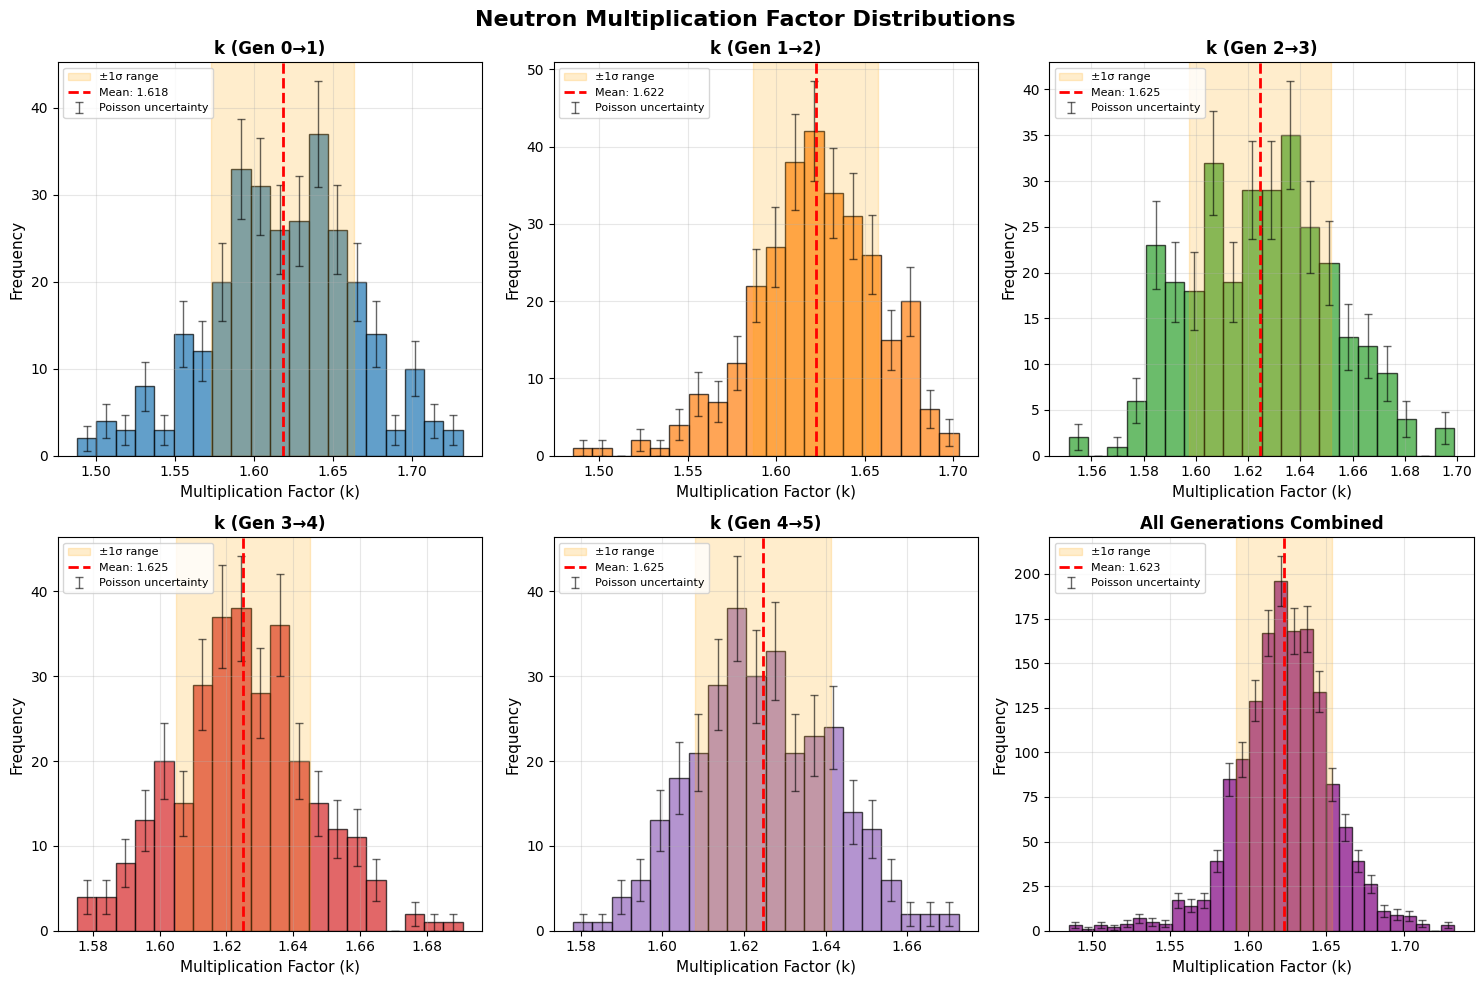


HISTOGRAM SUMMARY STATISTICS

All k values combined:
  Mean: 1.623
  Std:  0.031
  Min:  1.485
  Max:  1.732
  Median: 1.624


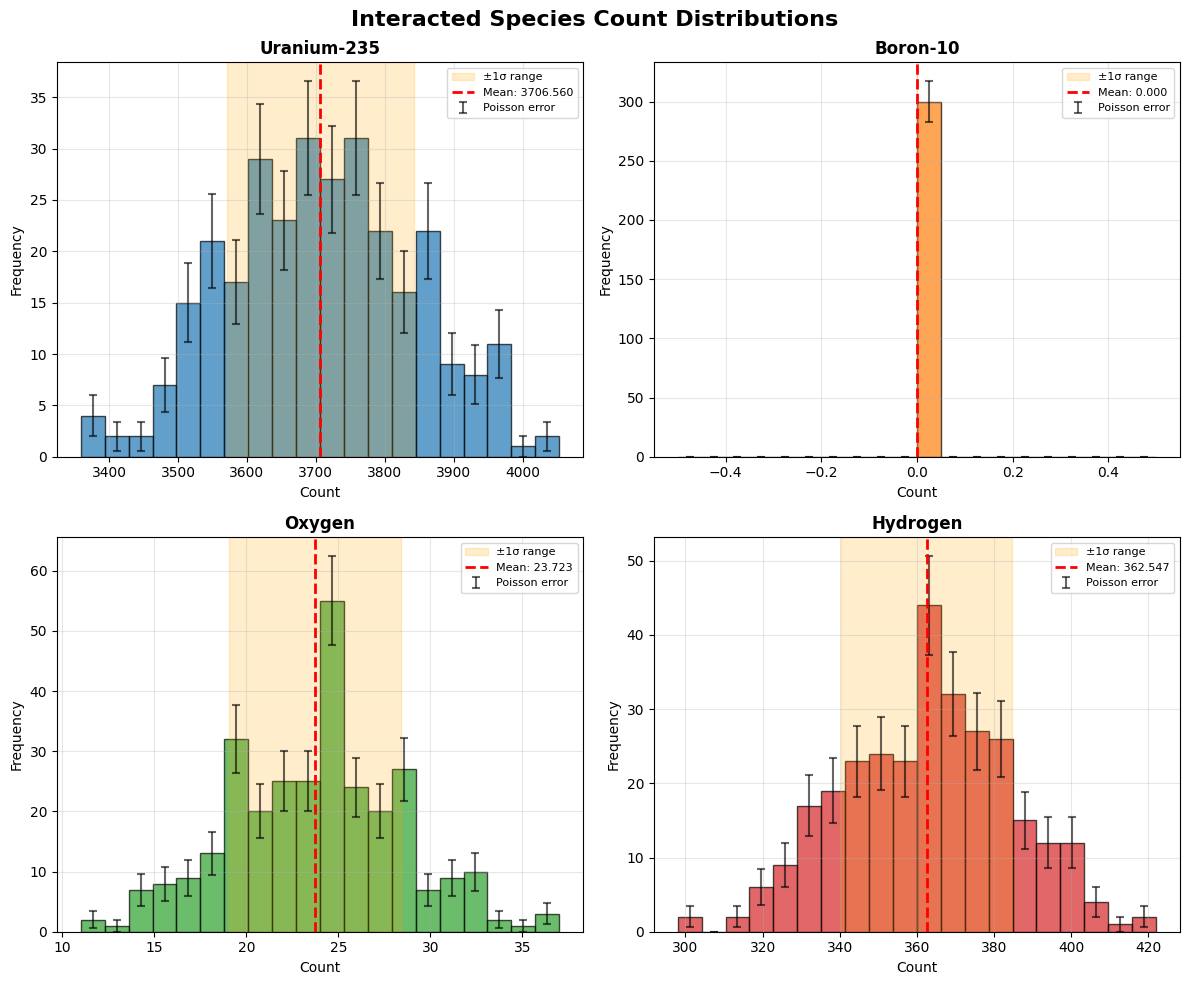


CONSUMED SPECIES SUMMARY STATISTICS

* Uranium-235: 3706 || std:  1.4e+02 
* Boron-10: 0 || std:  0 
* Oxygen: 23 || std:  4.7 
* Hydrogen: 362 || std:  22 



In [28]:
unumberdensity = 10e23
boronconc = 0
k1, k2, k3, k4, k5, means, stds, ucount,ocount,bcount,hcount,means1, stds1, mean_free_paths = run_simulation_multiple_nodisplay(boronconc,unumberdensity,300)

plot_histograms(k1, k2, k3, k4, k5, means, stds, "No")

plot_histograms_count(ucount,ocount,bcount,hcount,means1, stds1) 


**Figure 1**. Neutron multiplication factor distributions and interacting species count distributions when boron concentration is 0. 

##### Trial 1 Analysis
**Neutron Multiplication Factor**

We see from trial 1 that all multiplication factors are in the 1.6 to 1.63 range, indicating that the chain reaction is supercritical. The graphs look Gaussian-distributed, which is what we expect in a simulation involving probabilities. This is what we expect; without any boric acid, there is no mediator to contain the U235 fission reactions, leading to a very high multiplication factor. We see that the multiplication factors across the are around the same, with the mean being 1.623. 

**Interacted Species Count Distributions**

From the second graph, we see that a large proportion of interactions are those coming from uranium; there are no boron interactions (because there are no boron-10 atoms in the system), and the hydrogen and oxygen counts are in the hundreds and tens aof magnitude, respectively. This is what we expect! Looking at the micro and macroscopic cross sections for uranium, hydrogen, and oxygen (see "Programmed Code for Simulations"), those of uranium is far larger than that of hydrogen and oxygen. Therefore, any neutron will have a much higher probability of encountering uranium. This is why we need a non-zero boron acid concentration in the system; without it, the probability that the neutron will collide with a uranium will far overpower the other interactions, yielding a supercritical system.  

**Error Bars** 

We see that the error bars in our graphs are very large; this is due to low frequency count of each bin in our histogram, since standard deviation is $\sqrt{N}$: at small values of $N$ the relative standard deviation $\frac{\sqrt{N}}{N} = \frac{1}{\sqrt{N}}$ is high.

#### Trial 2: Boron Concentration = 150 ppm

Next, we increase boron concentration to 150 ppm. This increment was decided after some initial trials, where the distribution of boron interactions has slightly increased to non-zero (but still low) values.

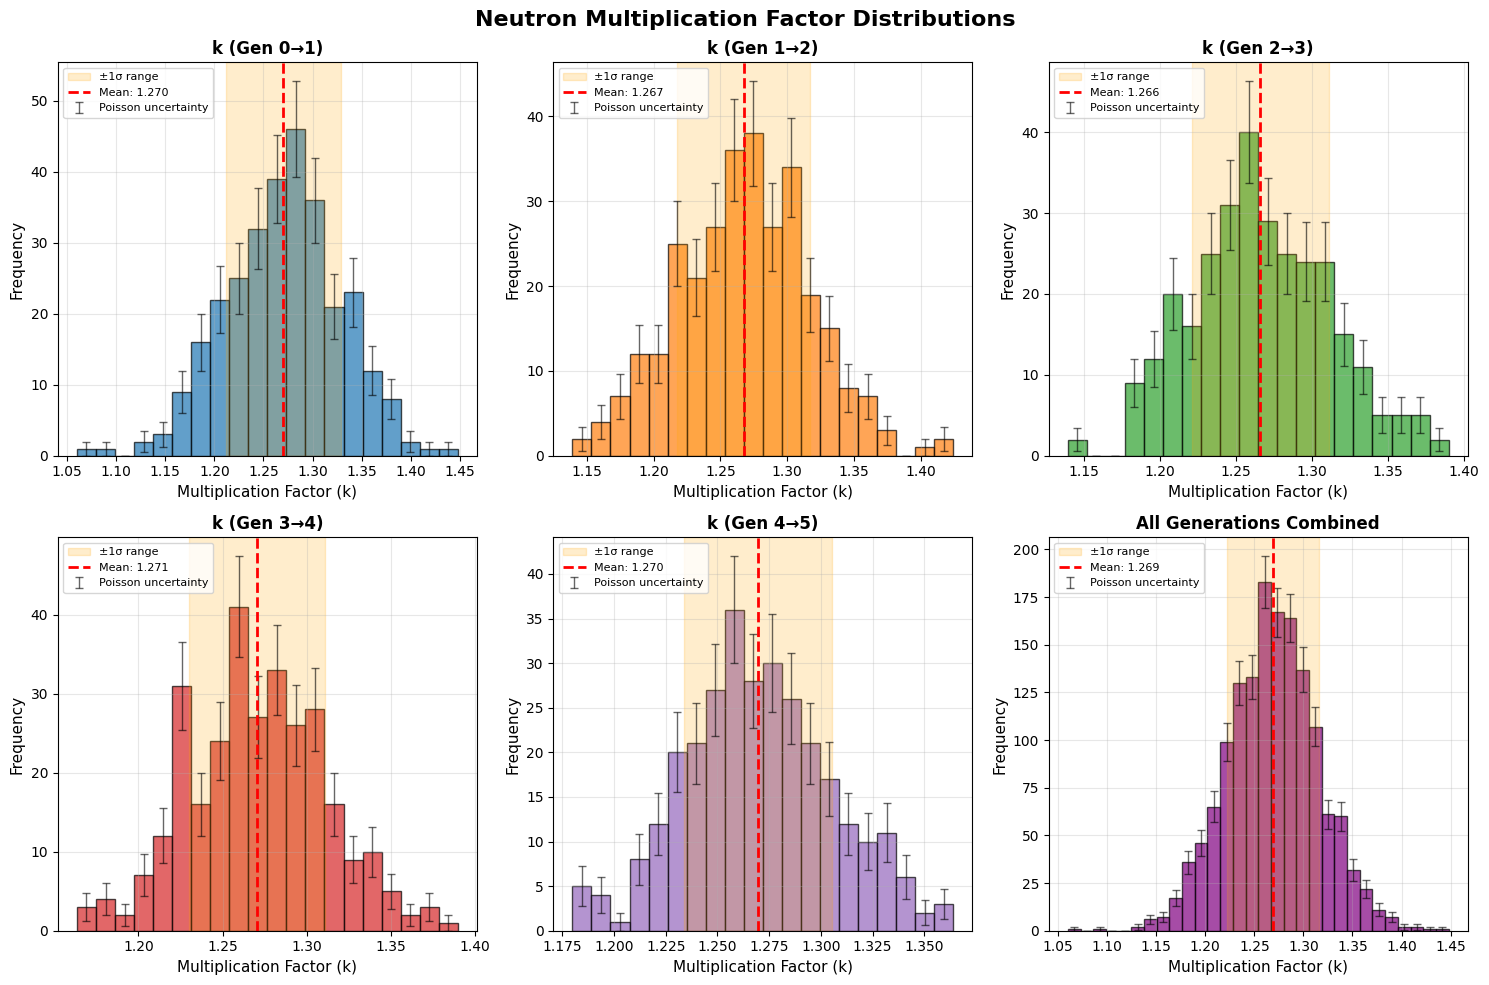


HISTOGRAM SUMMARY STATISTICS

All k values combined:
  Mean: 1.269
  Std:  0.047
  Min:  1.060
  Max:  1.448
  Median: 1.268


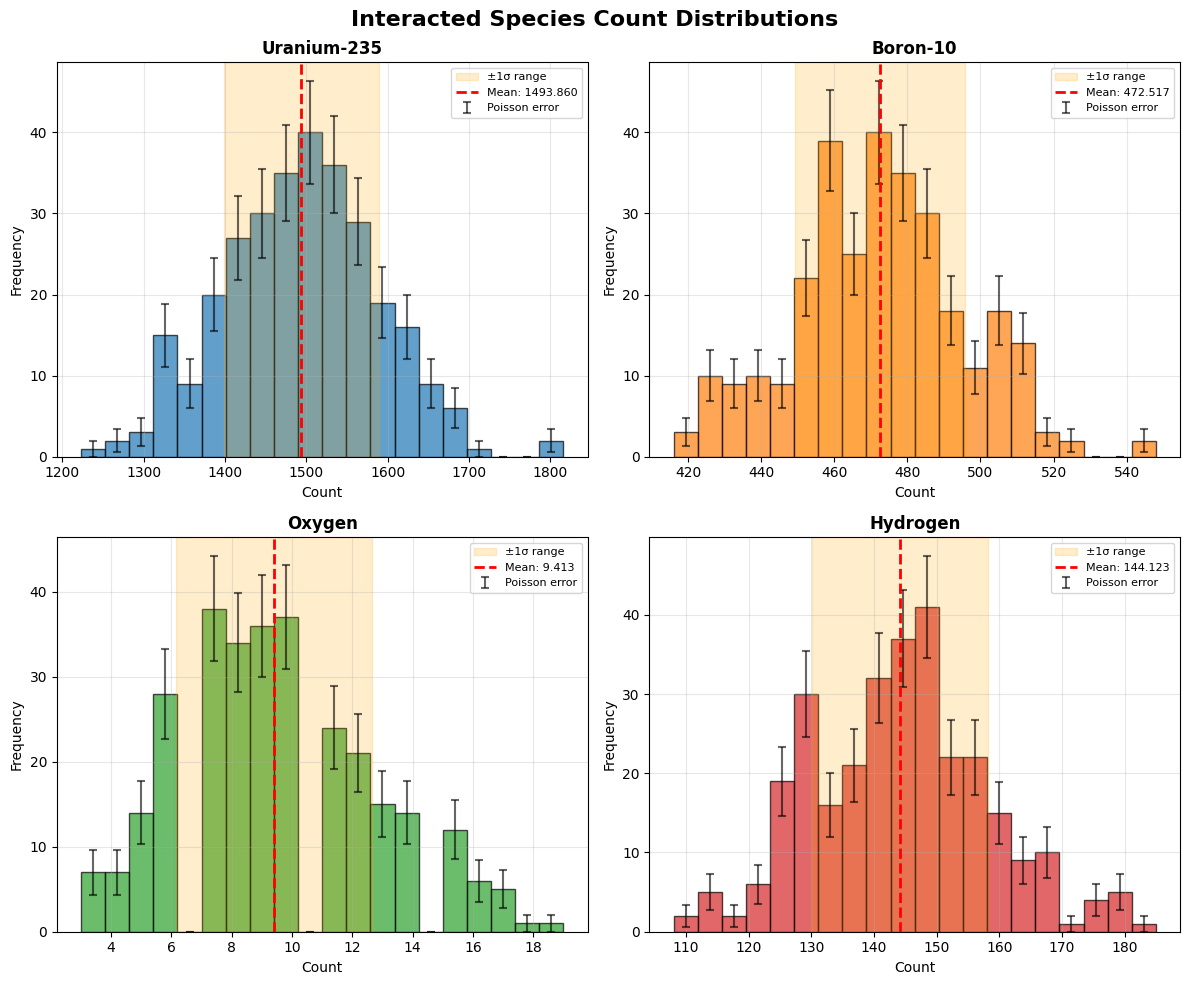


CONSUMED SPECIES SUMMARY STATISTICS

* Uranium-235: 1493 || std:  95 
* Boron-10: 472 || std:  23 
* Oxygen: 9 || std:  3.3 
* Hydrogen: 144 || std:  14 



In [30]:
unumberdensity = 10e23
boronconc = 150
k1, k2, k3, k4, k5, means, stds, ucount,ocount,bcount,hcount,means1, stds1, mean_free_paths = run_simulation_multiple_nodisplay(boronconc,unumberdensity,300)

plot_histograms(k1, k2, k3, k4, k5, means, stds, "No")

plot_histograms_count(ucount,ocount,bcount,hcount,means1, stds1) 

**Figure 2**. Neutron multiplication factor distributions and interacting species count distributions when boron concentration is 150 ppm. 

##### Trial 2 Analysis
**Neutron Multiplication Factor**

We see from trial 2 that all multiplication factors are in the 1.26 to 1.285 range, indicating that the chain reaction is supercritical. The graphs seem Gaussian-distributed, which is what we expect in a simulation involving probabilities. Notice how that the multiplication factor of this trial is less than that of trial 1; since there is a nonzero concentration of boric acid, we see that the borons can now capture travelling neutrons, removing them from the system.

**Interacted Species Count Distributions**

With the introduction of boric acid into the environment, we see that the number of interacted species for uranium, oxygen, and hydrogen is reduced. However, the ratio of  oxygens to hydrogen is still the same, since their relative probabilities are constant (although not to boron and uranium, since boron's total macroscopic cross section has increased from 0 to 6.6). Notice that the ratios of each of the species with each other is the same as that of their macroscopic cross sections; this is what we expect, since the macroscopic cross sections are exactly the measure of probabilities that the neutron will collide with each of the four atoms.

#### Trial 3: Boron Concentration = 500ppm

Finally, we increase boron concentration one more time. With this trial, we hope to observe what happens when the number of interactions with boron-10 increases past that of U-235.

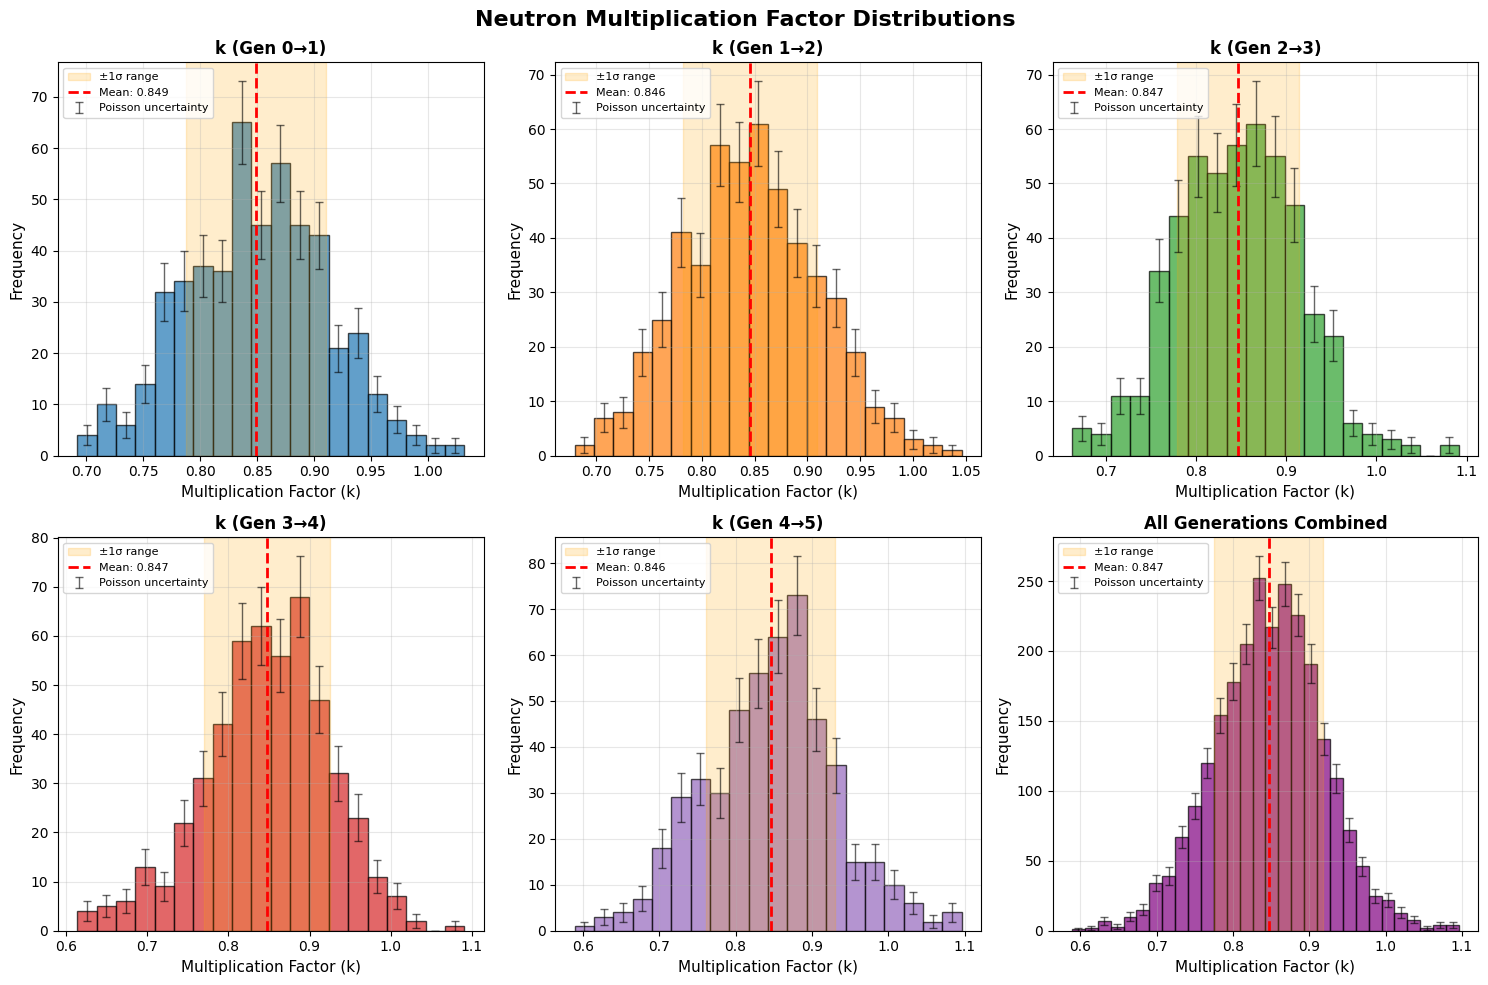


HISTOGRAM SUMMARY STATISTICS

All k values combined:
  Mean: 0.847
  Std:  0.071
  Min:  0.589
  Max:  1.096
  Median: 0.848


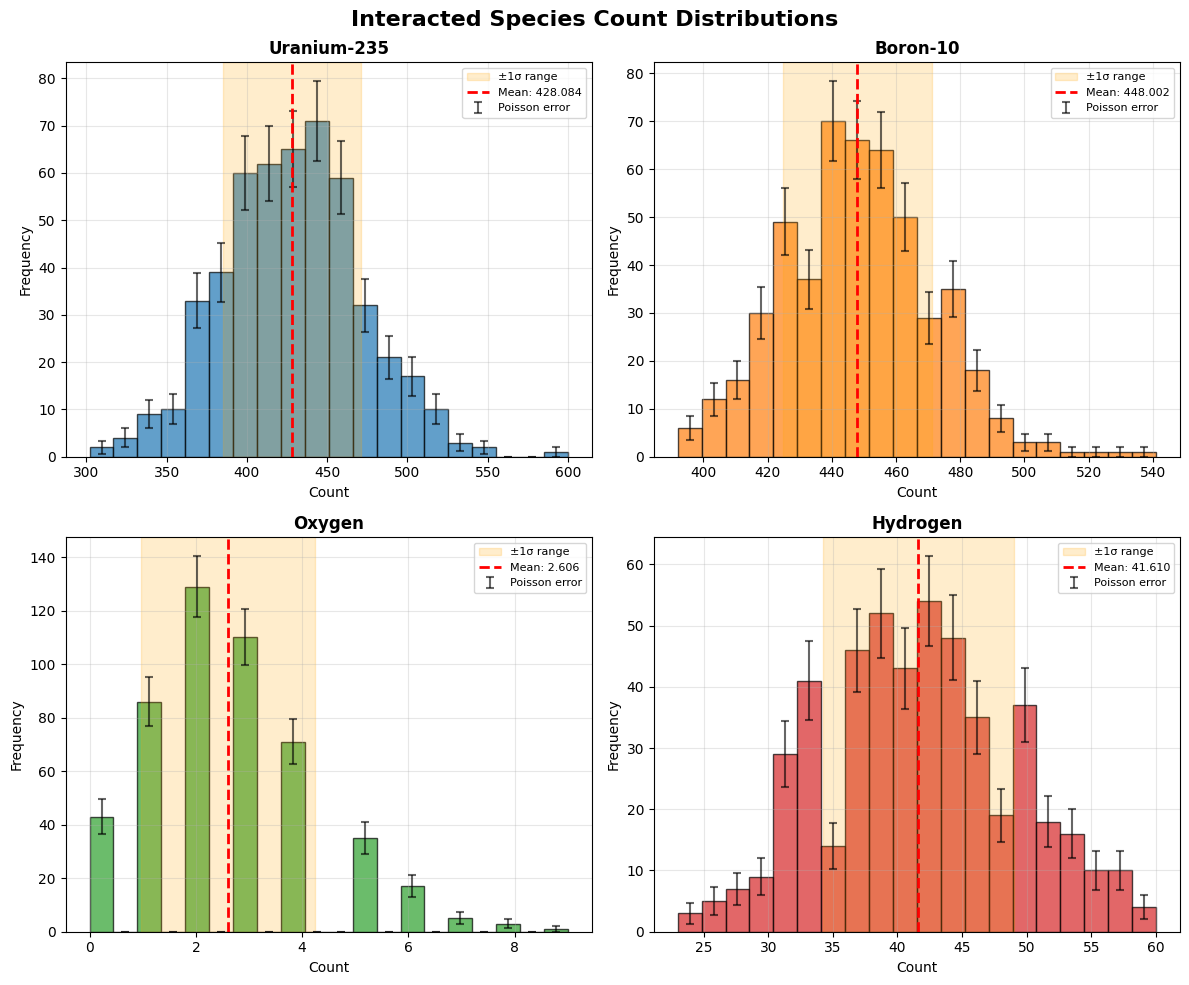


CONSUMED SPECIES SUMMARY STATISTICS

* Uranium-235: 428 || std:  43 
* Boron-10: 448 || std:  23 
* Oxygen: 2 || std:  1.6 
* Hydrogen: 41 || std:  7.4 



In [67]:
unumberdensity = 10e23
boronconc = 500
k1, k2, k3, k4, k5, means, stds, ucount,ocount,bcount,hcount,means1, stds1, mean_free_paths = run_simulation_multiple_nodisplay(boronconc,unumberdensity,500)

plot_histograms(k1, k2, k3, k4, k5, means, stds, "No")

plot_histograms_count(ucount,ocount,bcount,hcount,means1, stds1) 


**Figure 3**. Neutron multiplication factor distributions and interacting species count distributions when boron concentration is 500 ppm. 

#### Trial 3 Analysis 

**Neutron Multiplication Factor**

The same trends discussed in trial 2 can be seen in trial 3, and as expected, the multiplication factor is diminished further from trial 2. 

**Interacted Species Count Distribution**

The same trends discussed in trial 2 can been seen in trial 3, and as expected, the number of Boron-10 interactions has slightly surpassed that of the uranium.

#### Longitudinal Trend 

From our initial trials, we see that the multiplication factors are very similar to each other, and that they decrease as boron concentration increases. We extend this further by making a plot of all the multiplication factors and how they evolve over a range of boron concentrations from 0ppm to 1300ppm. 

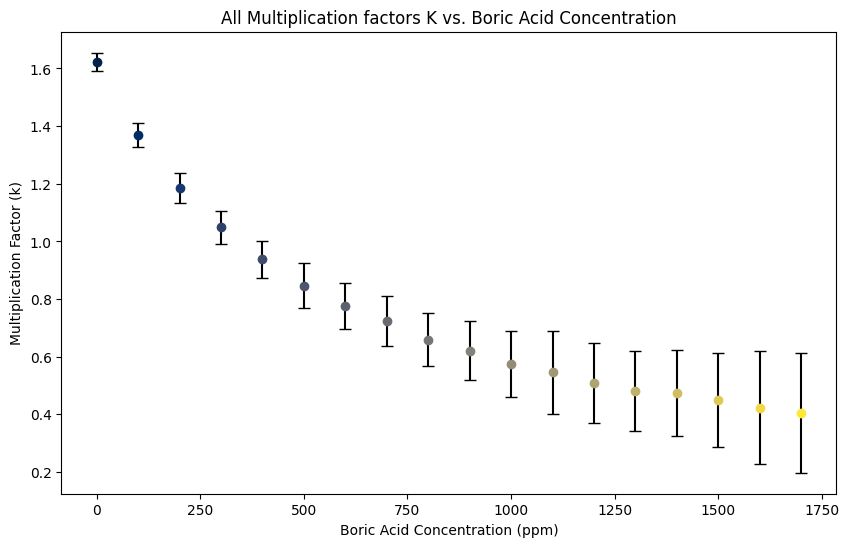

In [66]:
unumberdensity = 10e23

boronconc = [0,100,200,300,400,500,600,700,800,900,1000,1100,1200,1300, 1400, 1500, 1600, 1700]  
allk = []  
stdev = []

for conc in boronconc:  
    k1, k2, k3, k4, k5, means, stds, ucount,ocount,bcount,hcount,means1, stds1, mean_free_paths = run_simulation_multiple_nodisplay(conc,unumberdensity,100)
    all_k = np.concatenate([k1,k2,k3,k4,k5]) 
    std = np.std(all_k)
    stdev.append(std) 
    allk.append(all_k) 

plt.figure(figsize=(10, 6))

# Create colormap for the points
colors = plt.cm.cividis(np.linspace(0, 1, len(boronconc)))

for i, (conc, k_vals, std) in enumerate(zip(boronconc, allk, stdev)):
    plt.errorbar(conc, np.mean(k_vals), yerr=std, fmt='o', 
                 color=colors[i], ecolor='black', capsize=4)

plt.title("All Multiplication factors K vs. Boric Acid Concentration")
plt.xlabel("Boric Acid Concentration (ppm)")
plt.ylabel("Multiplication Factor (k)")
plt.show()

**Figure 4**. Plot of all multiplication factors as a function of boric acid concentration. Each data point corresponds to one parameter combination of boric acid concentration and uranium number density, where each simulation is run with 100 replications over 5 generations. The standard deviation over all k values calculated over these 100 replications is calculated for one parameter combination and plotted as an error bar.

From this graph, we notice that the multiplication factors decrease in an expoenential-like pattern. We also see that the standard deviation of multiplication factors increases as boron concentration increases. We expect that this is due to the decrease in events where the neutron interacts with uranium. When the number of events decreases, the sample size used for the probability is less, meaning that the "true probability" will be less representative of the actual new neutrons produced. As a result, the standard deviation of the k values will increase.  

Next, we look at how how multiplication factor and species distribution is affected when uranium number density changes and boron acid concentration is constant.

### Cycle 2: Boron Concentration = 100ppm, Uranium Number Density Varies  

We first start with low uranium number densities and increase it over the trials. 

#### Trial 1: Boron Concentration = 100ppm, Uranium Number Density = $10\text{e19}/cm^3$

For trial 1, we start with uranium number density being $10\text{e19}/cm^3$. We choose this number because after some initial tests with the simulation, we find that any number less than this number density yields very similar plots, where the number of consumed uranium is very nearly zero; this indicates that the macroscopic cross section of uranium compared to other species is negligible, so we pick the last number density order of magnitude where this still happens.

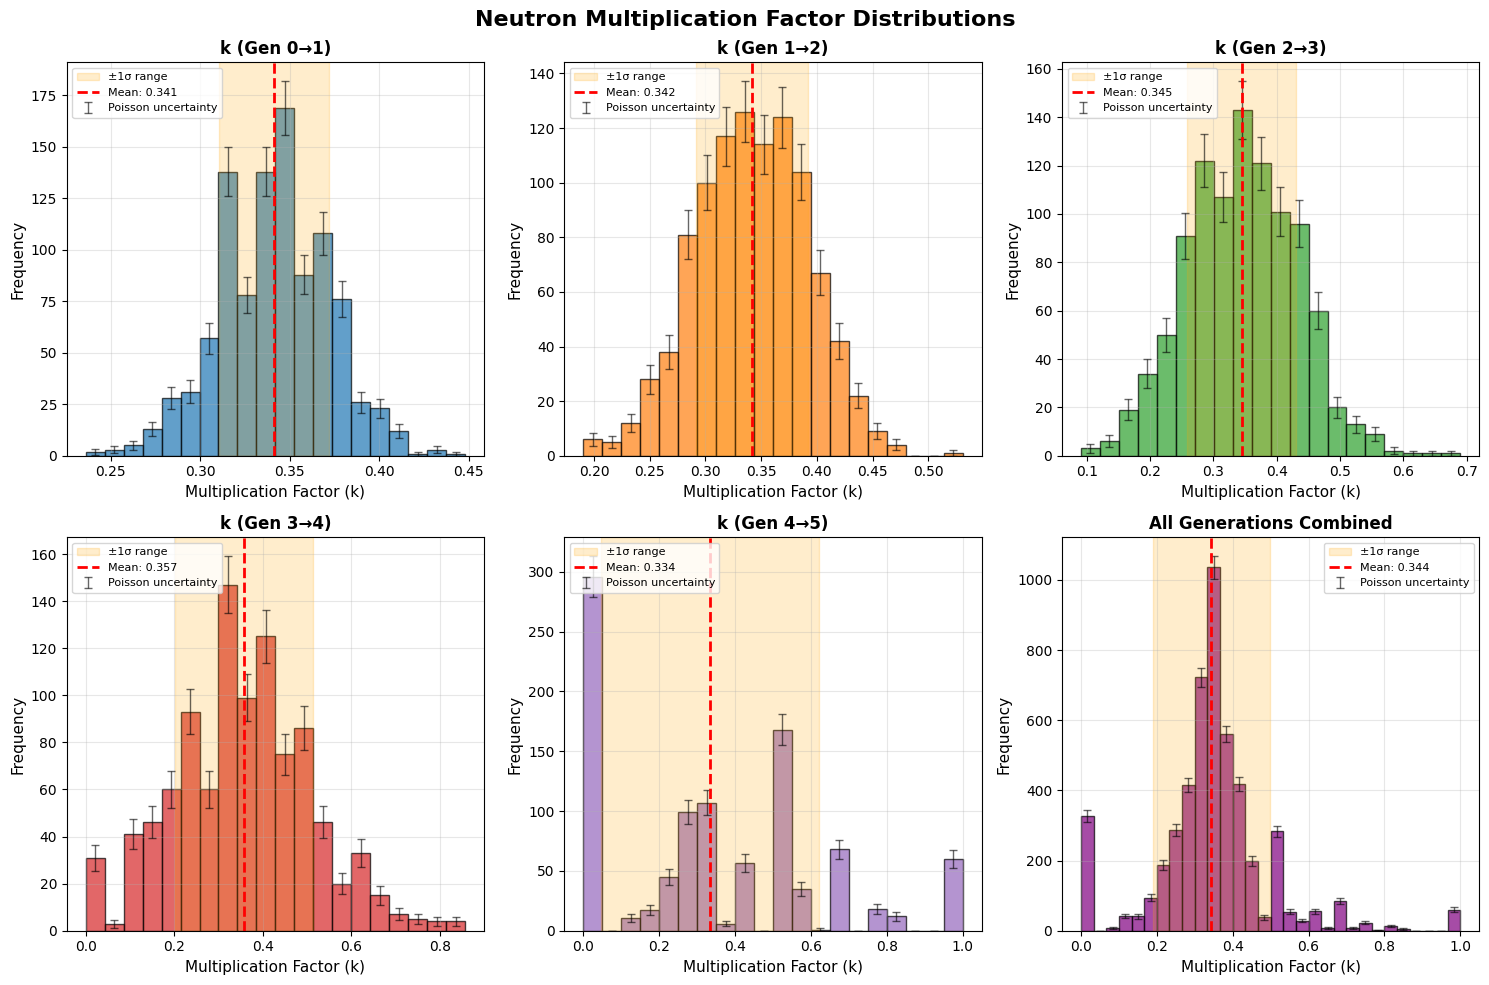


HISTOGRAM SUMMARY STATISTICS

All k values combined:
  Mean: 0.344
  Std:  0.154
  Min:  0.000
  Max:  1.000
  Median: 0.340


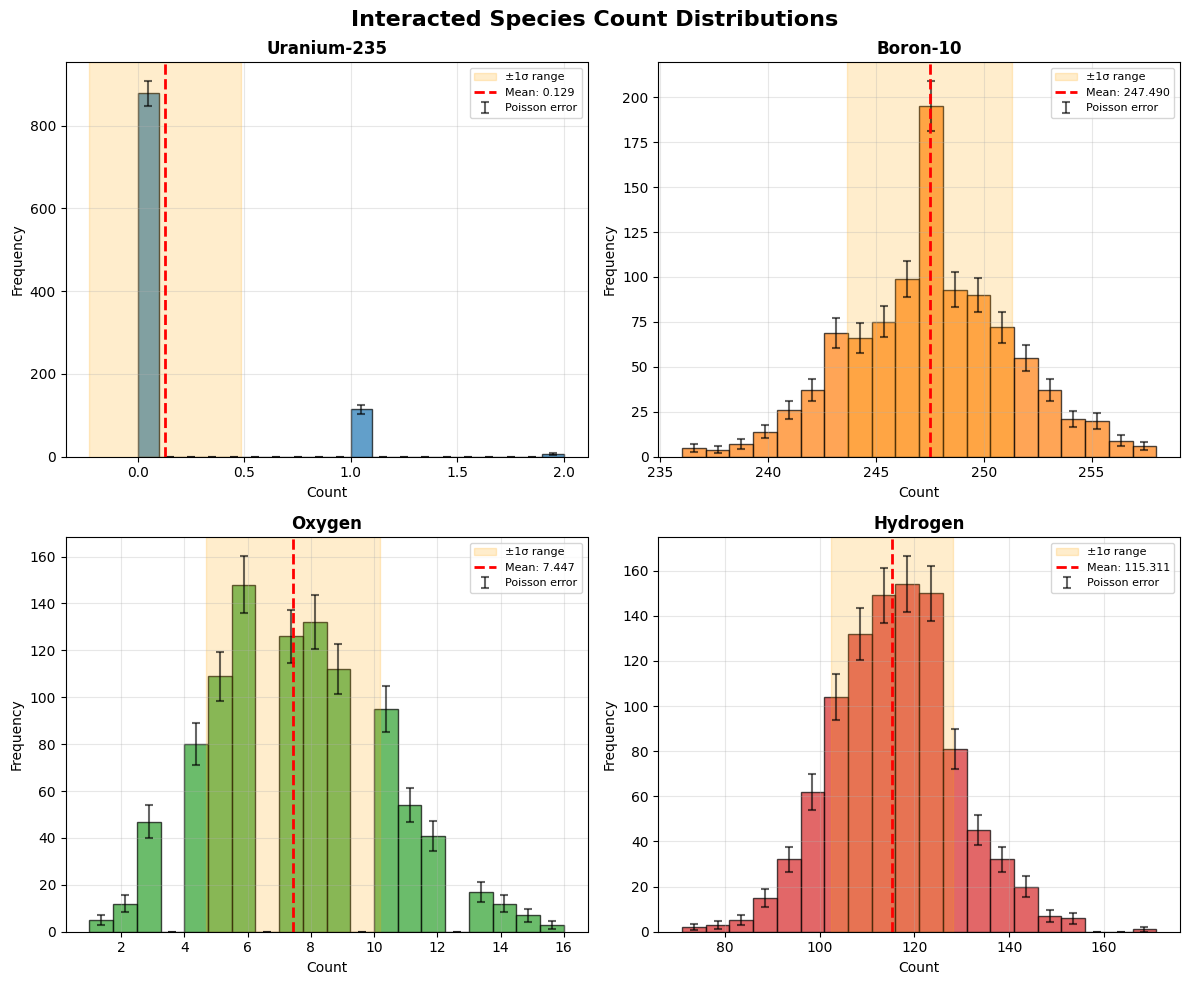


CONSUMED SPECIES SUMMARY STATISTICS

* Uranium-235: 0 || std:  0.36 
* Boron-10: 247 || std:  3.8 
* Oxygen: 7 || std:  2.7 
* Hydrogen: 115 || std:  13 



In [33]:
unumberdensity = 10e19
boronconc = 100
k1, k2, k3, k4, k5, means, stds, ucount,ocount,bcount,hcount,means1, stds1, mean_free_paths = run_simulation_multiple_nodisplay(boronconc,unumberdensity,1000)

plot_histograms(k1, k2, k3, k4, k5, means, stds, "No")

plot_histograms_count(ucount,ocount,bcount,hcount,means1, stds1) 


**Figure 5**. Neutron multiplication factor and interacted species count distributions when uranium number density is 10e19/cm^3.

##### Trial 1 Analysis

**Neutron Multiplication Factor**

We see that in trial 1, the multiplication factor ranges between 0.34 and 0.36, indicating that the system is subcritical. This is what we expect; when uranium number density is very low, few (or even none!) neutrons undergo fission, meaning that all of the surviving neutrons is due to elastic scattering. Since elastic scattering does not add an extra neutron into the system, this leads to the multiplication factor being very low.

**Interacted Species Count Distributions**

From the second graph, we see that no uraniums partake in interactions with neutrons. This is very interesting! This tells us that the number density of uranium 235 is so low that the macroscopic cross section of uranium 235 is negligible compared to the other three atoms. Instead, all of surviving neutrons are a result of elastic scattering of either boron, hydrogen, or oxygen. 

#### Trial 2: Boron Concentration = 100 ppm, Uranium Number Density = $10\text{e21}/cm^3$ 

For trial 2, we want to slightly increase uranium number density such that the number of neutrons that interact with u-235 is still less than the same as that of boron-10, but is now mostly non-zero. After some trial experimenting, we find that $10\text{e21}/cm^3$ is a suitable value.

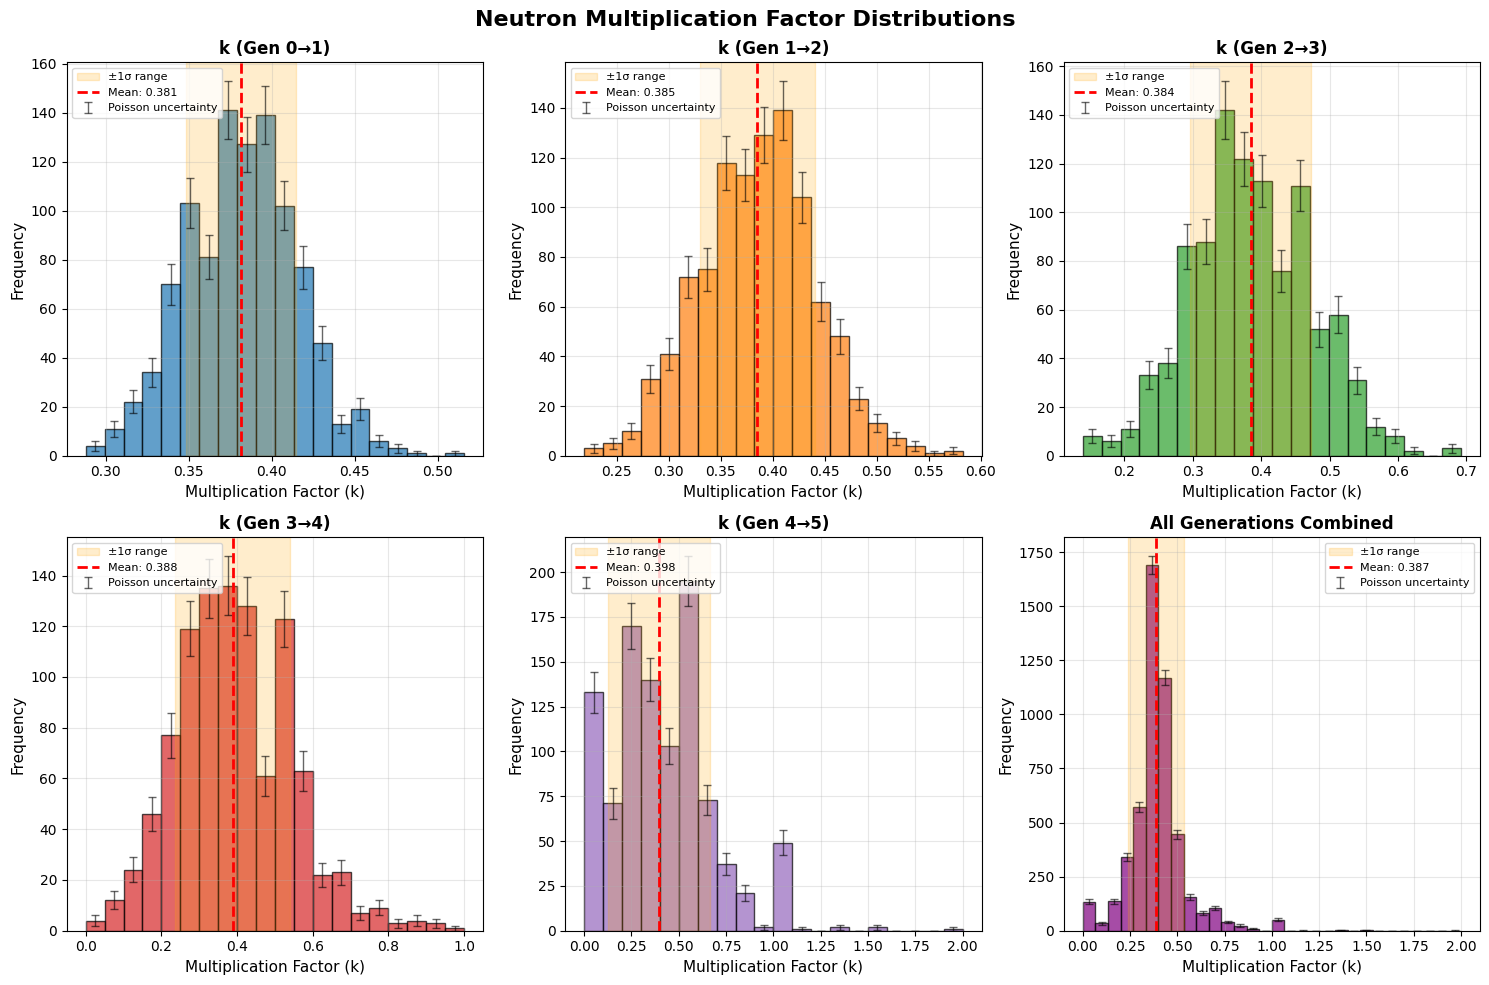


HISTOGRAM SUMMARY STATISTICS

All k values combined:
  Mean: 0.387
  Std:  0.147
  Min:  0.000
  Max:  2.000
  Median: 0.381


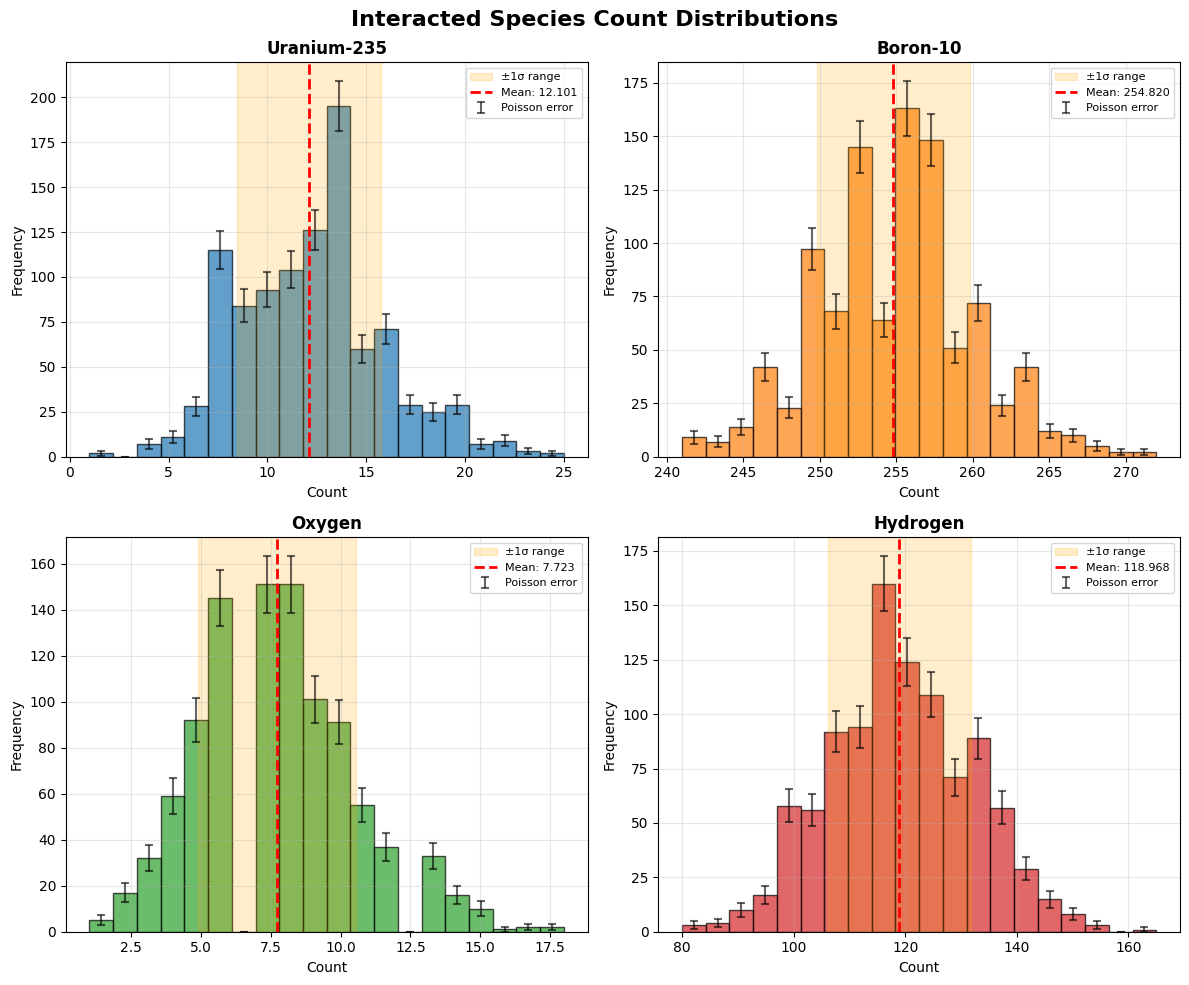


CONSUMED SPECIES SUMMARY STATISTICS

* Uranium-235: 12 || std:  3.6 
* Boron-10: 254 || std:  5 
* Oxygen: 7 || std:  2.8 
* Hydrogen: 118 || std:  13 



In [34]:
unumberdensity = 10e21
boronconc = 100
k1, k2, k3, k4, k5, means, stds, ucount,ocount,bcount,hcount,means1, stds1, mean_free_paths = run_simulation_multiple_nodisplay(boronconc,unumberdensity,1000)

plot_histograms(k1, k2, k3, k4, k5, means, stds, "No")

plot_histograms_count(ucount,ocount,bcount,hcount,means1, stds1) 


**Figure 6**. Neutron multiplication factor and interacted species count distributions when uranium number density is 10e21/cm^3.

##### Trial 2 Analysis

**Neutron Multiplication Factor**

We see that in trial 2, the multiplication factor ranges between 0.38 and 0.40, indicating that the system is still subcritical. However, the multiplication factor is increasing, since the number of uranium atoms in the system is increasing. This increases the macroscopic cross section of uranium.

**Interacted Species Count Distributions**

We see that although the number of interacted uraniums is still very little, it is now a nonzero number. The ratios of oxygen, hydrogen, and boron count is still proportional to their macroscopic cross sections, which is what we expect (discussed in cycle 1).

#### Trial 3: Boron Concentration = 100 ppm, Uranium Number Density = $10\text{e23}/cm^3$

For trial 3, given that we have increased two orders of magnitude from trial 1 and trial 2, we do the same thing between trials 2 and 3 to increase uranium number density $10\text{e23}/cm^3$. From this, we can understand preliminarily if the increase in multiplication factor is linear or characterized by some other relationship.


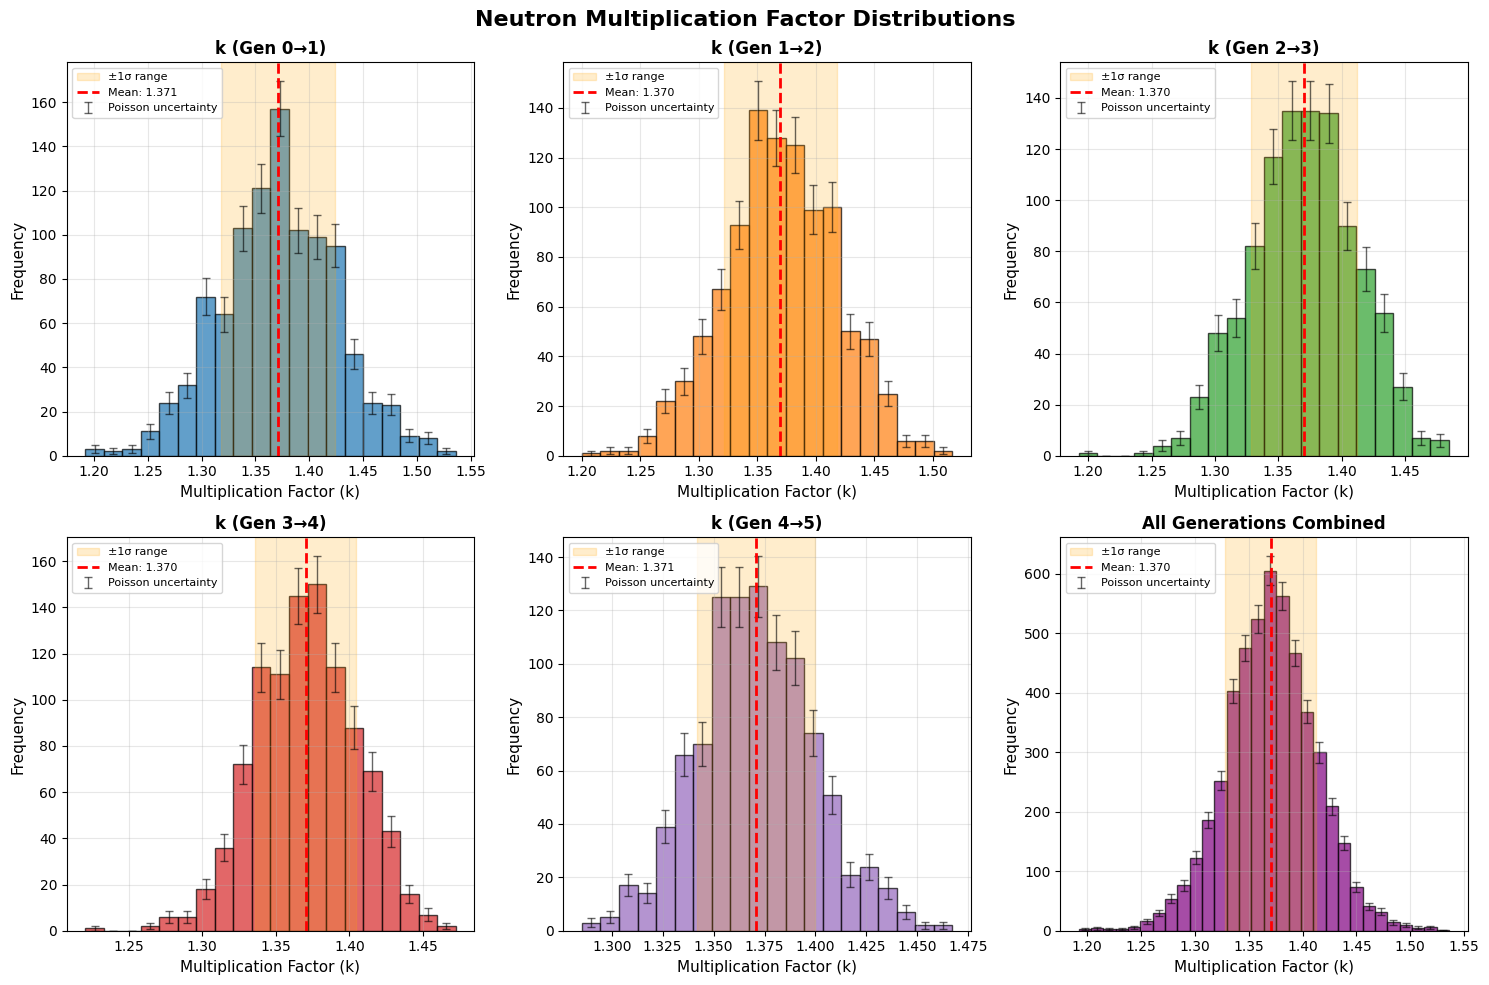


HISTOGRAM SUMMARY STATISTICS

All k values combined:
  Mean: 1.370
  Std:  0.042
  Min:  1.192
  Max:  1.536
  Median: 1.370


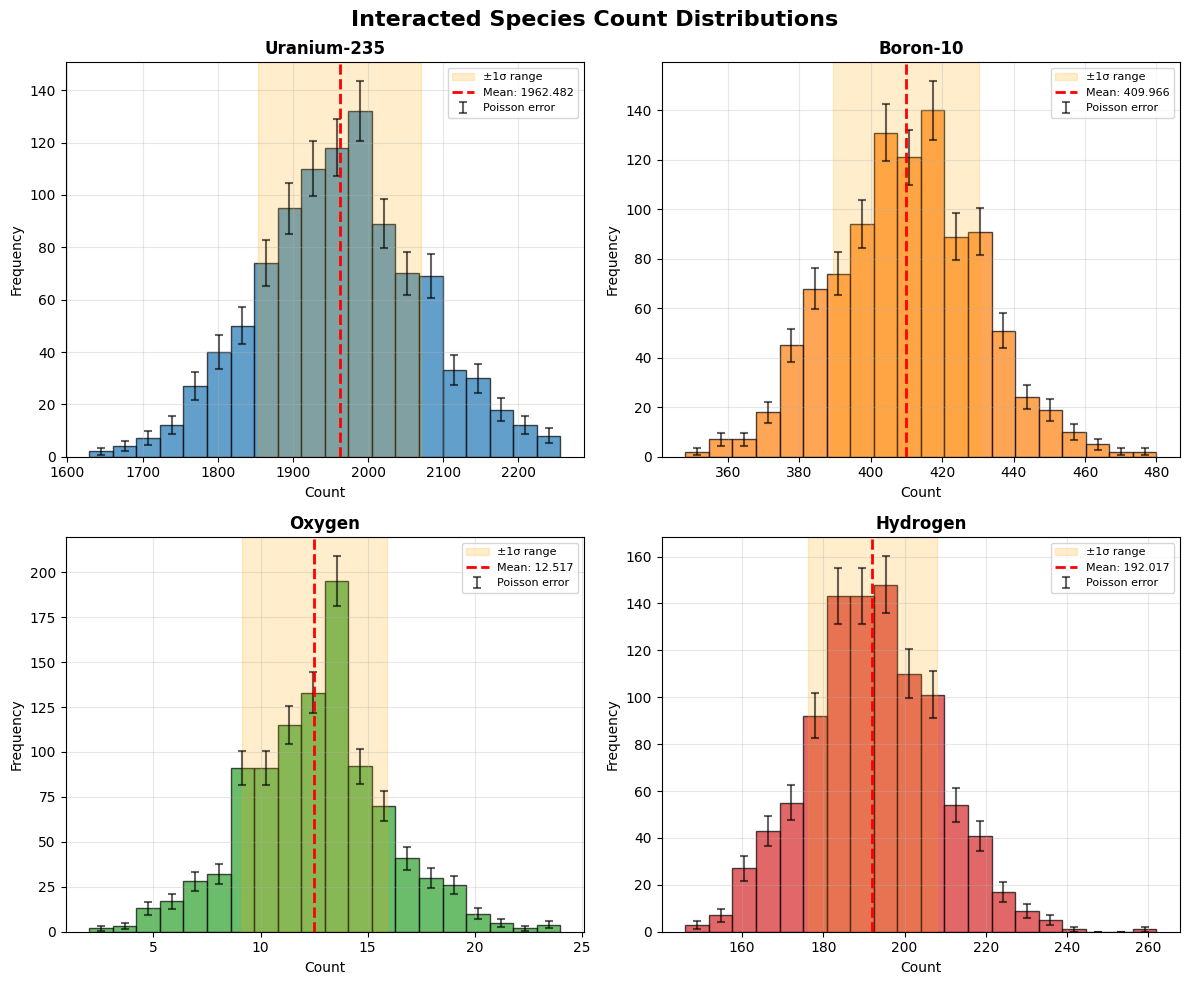


CONSUMED SPECIES SUMMARY STATISTICS

* Uranium-235: 1962 || std:  1.1e+02 
* Boron-10: 409 || std:  20 
* Oxygen: 12 || std:  3.4 
* Hydrogen: 192 || std:  16 



In [36]:
unumberdensity = 10e23
boronconc = 100
k1, k2, k3, k4, k5, means, stds, ucount,ocount,bcount,hcount,means1, stds1, mean_free_paths = run_simulation_multiple_nodisplay(boronconc,unumberdensity,1000)

plot_histograms(k1, k2, k3, k4, k5, means, stds, "No")

plot_histograms_count(ucount,ocount,bcount,hcount,means1, stds1) 


**Figure 7**. Neutron multiplication factor and interacted species count distributions when uranium number density is 10e23/cm^3.

##### Trial 3 Analysis

**Neutron Multiplication Factor**

As expected, the multiplication factor increases. In fact, we see that there is a very big spike in multiplication factor; it is now in the range of 1.37 and 1.372, and the system is supercritical! It is most likely that the spike is due to the increase in uranium fissions; unlike elastic scattering, uranium fission produces two neutrons, meaning that 1 uranium fission is equivalent to the effect of 1 elastic scatters. Hence, the multiplication factors skyrockets as the number of uranium counts increases. This tell us that the increase in multiplication factor is not linear. This is further explored in the longitudinal trend below.

**Interacted Species Count Distributions**

We see that the number of uranium interactions now dominates the other atoms.

#### Longitudinal Trend 

We then conduct a longitudinal trend analysis, setting boron concentration to be 0, and setting uranium density to be a range of values from 10e17 to 10e25

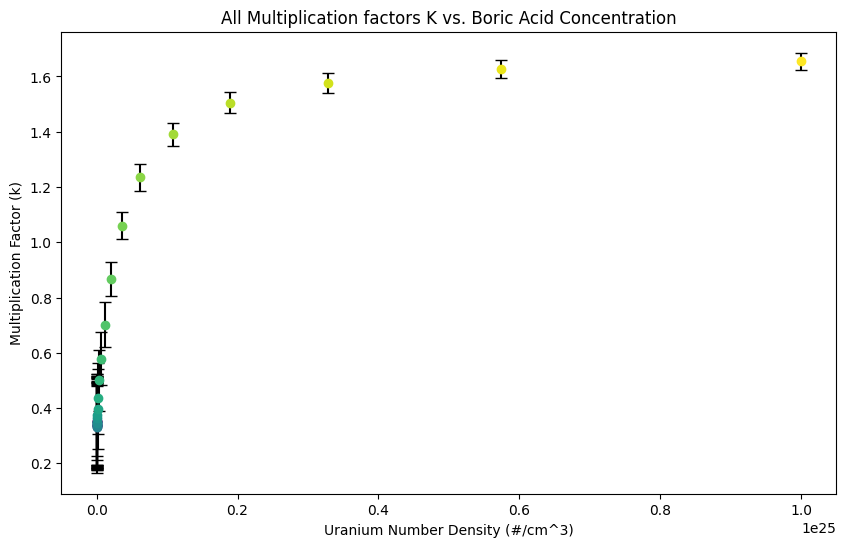

In [64]:
unumberdensity = np.logspace(18,25,30)

boronconc = 100  

allk = []  
stdev = []

for u in unumberdensity:  
    k1, k2, k3, k4, k5, means, stds, ucount,ocount,bcount,hcount,means1, stds1, mean_free_paths = run_simulation_multiple_nodisplay(boronconc,u,100)
    all_k = np.concatenate([k1,k2,k3,k4,k5]) 
    std = np.std(all_k)
    stdev.append(std) 
    allk.append(all_k) 

plt.figure(figsize=(10, 6))

# Create colormap for the points
colors = plt.cm.viridis(np.linspace(0, 1, len(unumberdensity)))

for i, (unumberdensity, k_vals, std) in enumerate(zip(unumberdensity, allk, stdev)):
    plt.errorbar(unumberdensity, np.mean(k_vals), yerr=std, fmt='o', 
                 color=colors[i], ecolor='black', capsize=4)

plt.title("All Multiplication factors K vs. Boric Acid Concentration")
plt.xlabel("Uranium Number Density (#/cm^3)")
plt.ylabel("Multiplication Factor (k)")
plt.show()

**Figure 9**. Longitudinal plot graphing multiplication factor vs uranium number density.

From our longitudinal plot, we see that the multiplication factors follow a somewhat logarithmic relationship, where the multiplication factor increases and then stabilize at roughly 1.7.

Why might this be? To understand this, we run two different trials with very high uranium number density to observe their similarities and differences. We execute the simulation when uranium number density is 10e26/cm^3 and 10e27/cm^3:

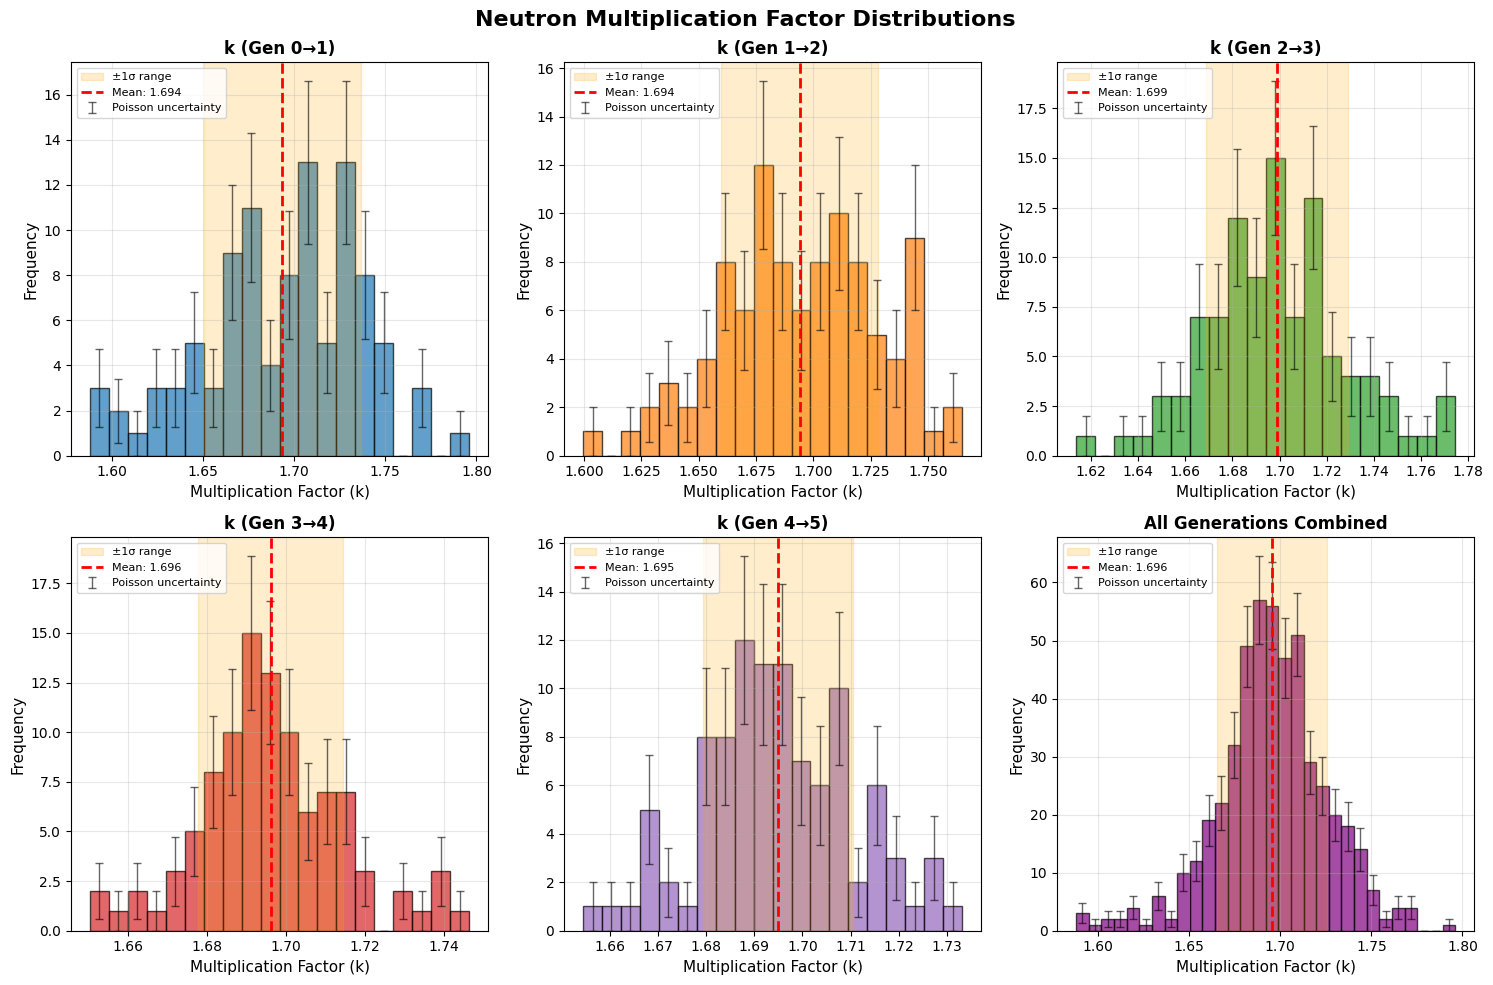


HISTOGRAM SUMMARY STATISTICS

All k values combined:
  Mean: 1.696
  Std:  0.030
  Min:  1.588
  Max:  1.796
  Median: 1.696


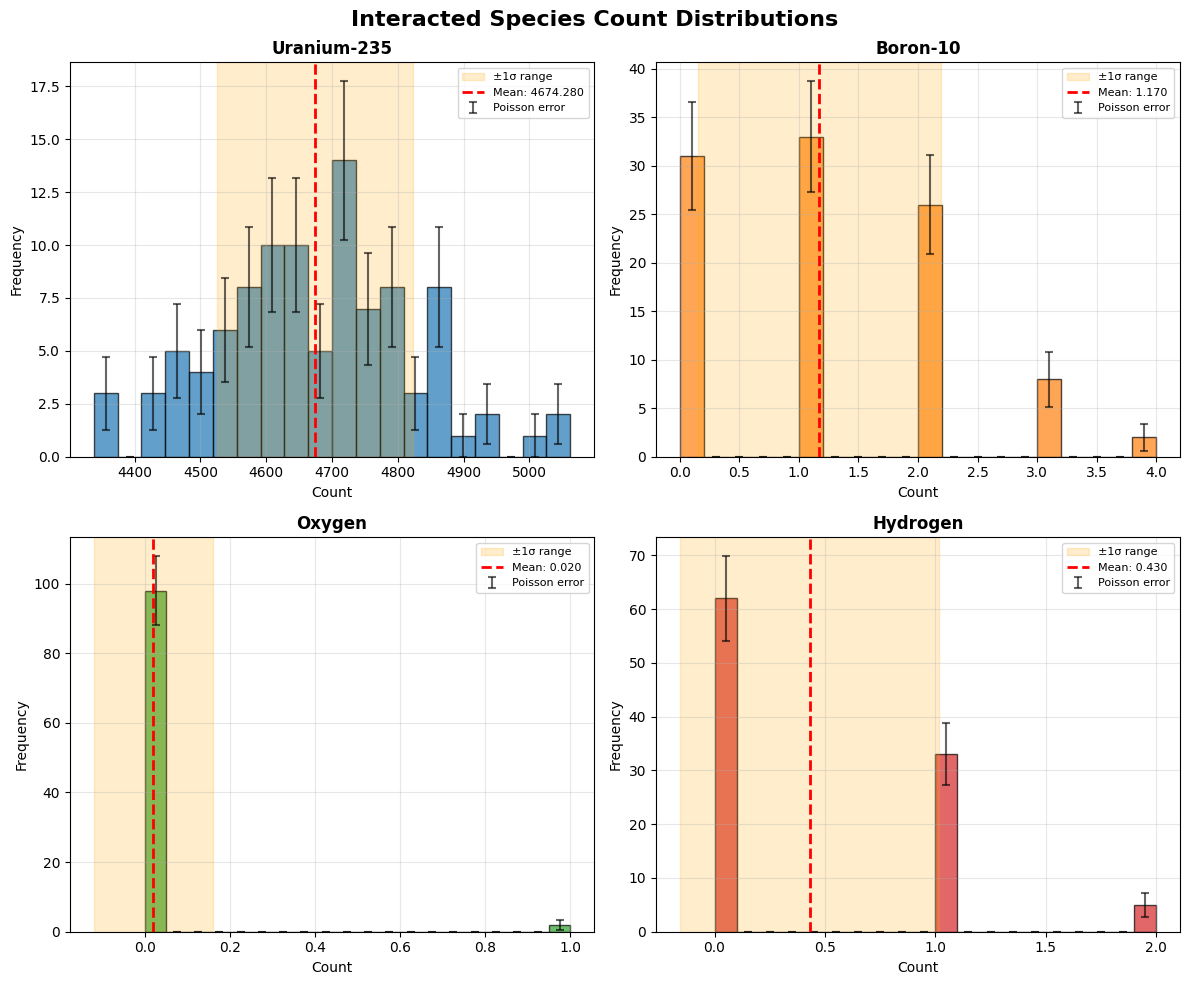


CONSUMED SPECIES SUMMARY STATISTICS

* Uranium-235: 4674 || std:  1.5e+02 
* Boron-10: 1 || std:  1 
* Oxygen: 0 || std:  0.14 
* Hydrogen: 0 || std:  0.59 



In [37]:
#10e24

unumberdensity = 10e26
boronconc = 100
k1, k2, k3, k4, k5, means, stds, ucount,ocount,bcount,hcount,means1, stds1, mean_free_paths = run_simulation_multiple_nodisplay(boronconc,unumberdensity,100)

plot_histograms(k1, k2, k3, k4, k5, means, stds, "No")

plot_histograms_count(ucount,ocount,bcount,hcount,means1, stds1) 


**Figure 10**. Neutron multiplication factor and interacted species count distributions when uranium number density is 10e26/cm^3.

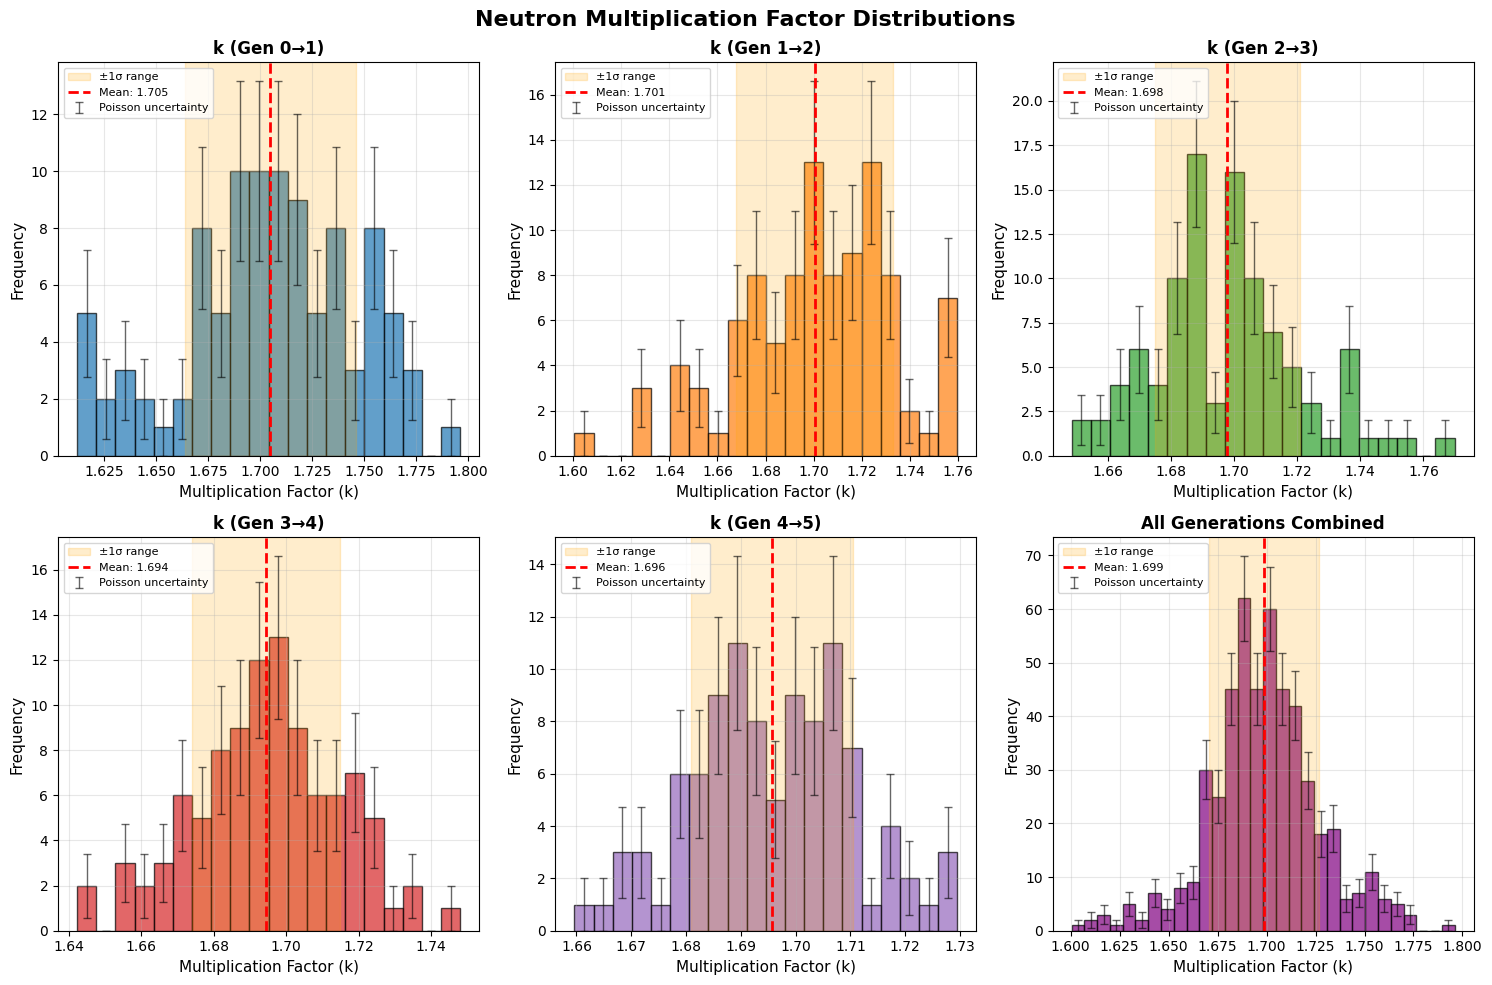


HISTOGRAM SUMMARY STATISTICS

All k values combined:
  Mean: 1.699
  Std:  0.028
  Min:  1.600
  Max:  1.796
  Median: 1.699


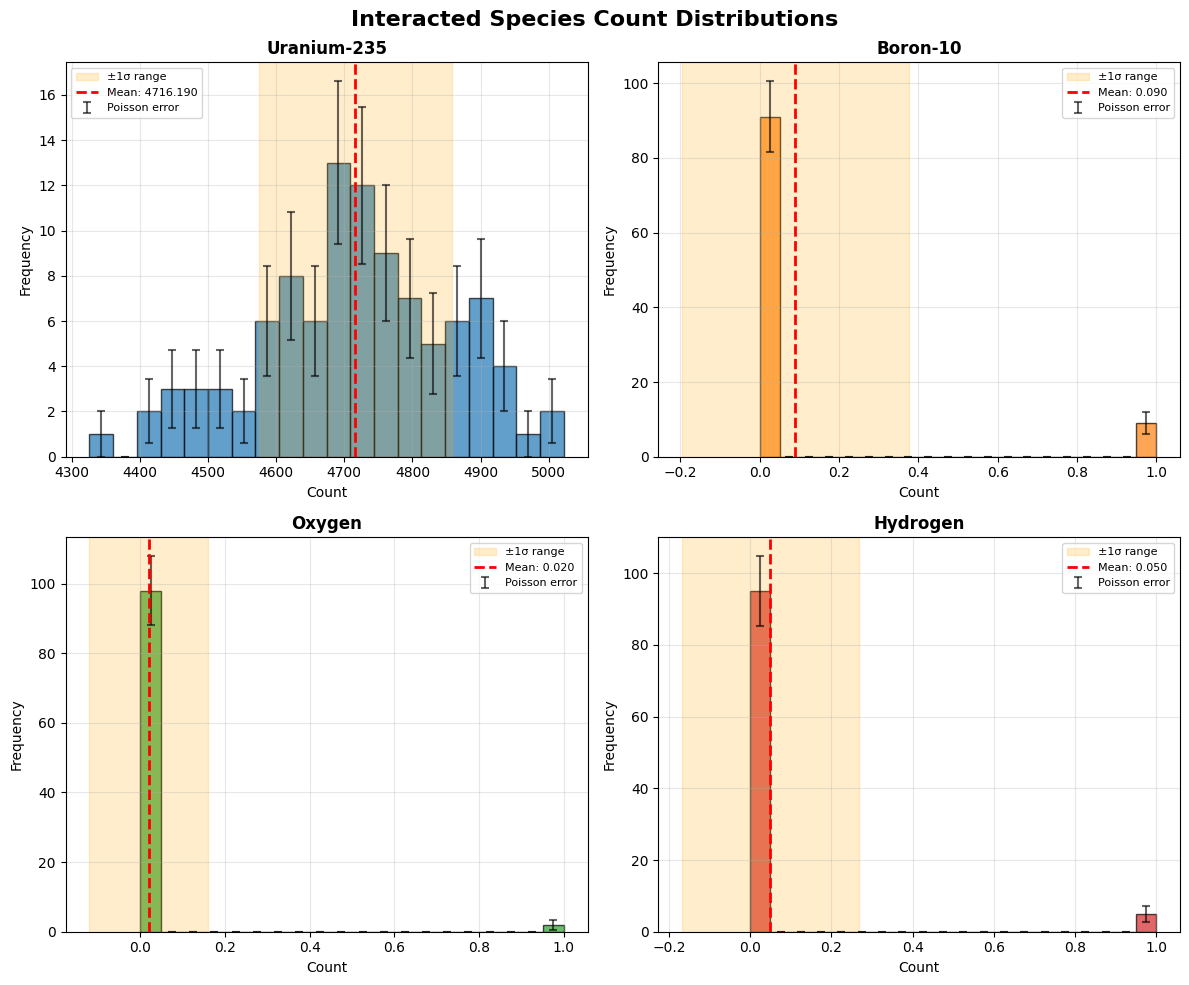


CONSUMED SPECIES SUMMARY STATISTICS

* Uranium-235: 4716 || std:  1.4e+02 
* Boron-10: 0 || std:  0.29 
* Oxygen: 0 || std:  0.14 
* Hydrogen: 0 || std:  0.22 



In [38]:
#10e24

unumberdensity = 10e27
boronconc = 100
k1, k2, k3, k4, k5, means, stds, ucount,ocount,bcount,hcount,means1, stds1, mean_free_paths = run_simulation_multiple_nodisplay(boronconc,unumberdensity,100)

plot_histograms(k1, k2, k3, k4, k5, means, stds, "No")

plot_histograms_count(ucount,ocount,bcount,hcount,means1, stds1) 


#####

**Figure 11**. Neutron multiplication factor and interacted species count distributions when uranium density is 10e27/cm^3. 

Looking at the statistics outputted from these graphs, we see that nearly all (if not all) of the consumed species is uranium-235. This helps explain why the multiplication factor becomes constant at very high number densities; if all consumed species are uranium, then the only variable for consumed species in generation 0 is the number of starting neutrons, which is the same for all simulations. Furthermore, given there is a large enough sample size of consumed uranium-235 then, we can expect that the count of each of the three processes of uranium will be roughly the same as well. Altogether then, since each uranium reaction will have approximately the same number of reactions and the number of surviving neutrons per generation should be approximately the same across both trials, that average multiplication factors will be very similar, with their trends flattening as uranium number density increases.

## Part II. Quantitative Phase Space Analysis  

In our second part of analysis, we execute four quantitative phase space scans using a range of different combinations of uranium number density and boric acid concentration. We first conduct the quantitative phase space scan for multiplication factor, then do it for each of the four species: uranium, boron, oxygen, and hydrogen. 

### Phase Space 1: Multiplication Factors

**Figure 12**. (Top) Quantitative 2-D Phase Space, with neutron multiplication factor as a function of uranium number density and boron concentration. (Bottom) Plot of all combinations of uranium number density and boric acid concentration such that the multiplication factor is within 1% of a factor of $k=1$. These were run in a different terminal and is higher resolution than the above graph.

====================== QUANTITATIVE PHASE SPACE SCAN FOR MULTIPLICATION FACTOR ======================= 

2D QUANTITATIVE PHASE SPACE SCAN: Multiplication Factor


Scan completed in 952.9s (15.9 min)
Average: 0.10s per simulation


Figure saved as 'phase_space_heatmap.png'


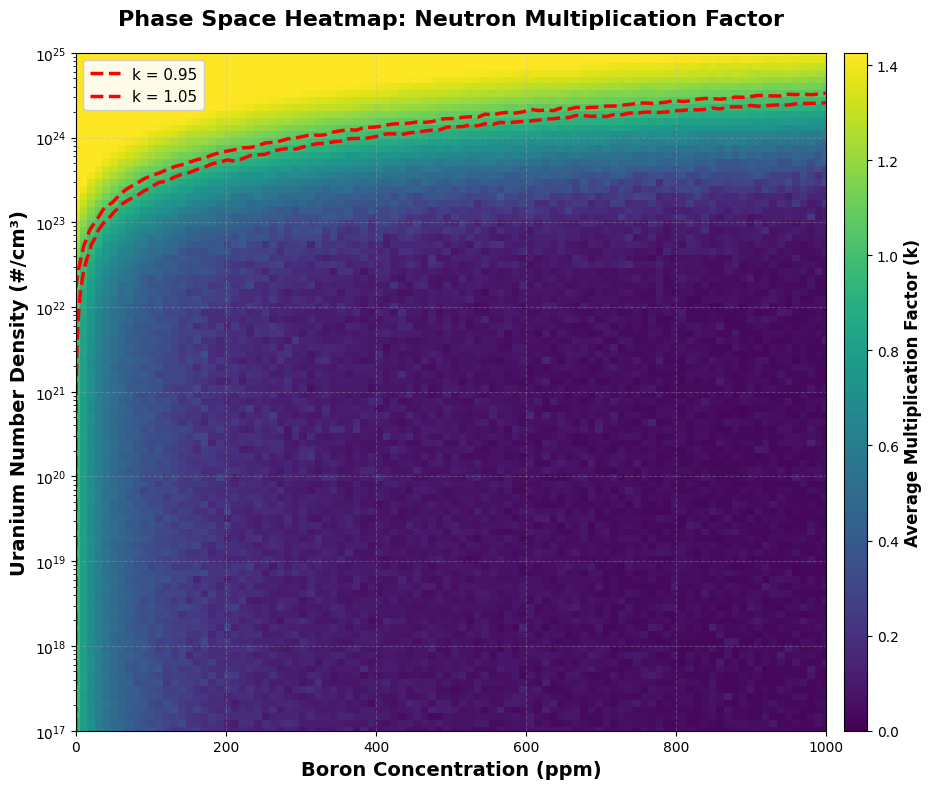

Figure saved as 'critical_points.png' with 30 points


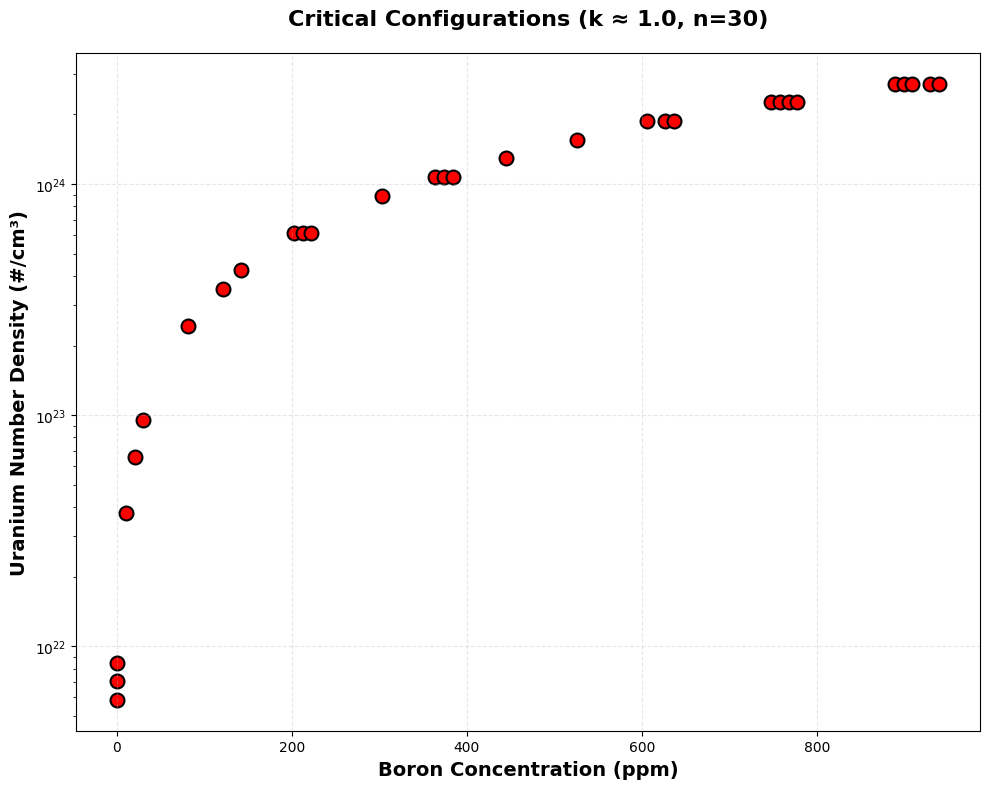

In [50]:
# Define the function FIRST
def plot_one(one):
    plt.close('all')  # Close any existing figures first
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    if len(one) > 0:
        one_array = np.array(one)
        
        ax.scatter(
            one_array[:, 0],  # boron values
            one_array[:, 1],  # uranium values
            s=100,
            color='red',
            marker='o',
            edgecolors='black',
            linewidths=1.5
        )
    else:
        print("No critical configurations found (list 'one' is empty)")
    
    ax.set_xlabel('Boron Concentration (ppm)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Uranium Number Density (#/cm³)', fontsize=14, fontweight='bold')
    ax.set_title(f'Critical Configurations (k ≈ 1.0, n={len(one)})', 
                 fontsize=16, fontweight='bold', pad=20)
    
    ax.set_yscale('log')
    ax.grid(True, linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('critical_points.png', dpi=300, bbox_inches='tight')
    print(f"Figure saved as 'critical_points.png' with {len(one)} points")
    return fig




def plot_phase_space_heatmap(results_grid, boron_range, uranium_range):
    import matplotlib.colors as mcolors
    from matplotlib.lines import Line2D
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Create meshgrid — boron on x-axis, uranium on y-axis
    boron_grid, uranium_grid = np.meshgrid(boron_range, uranium_range)

    
    # Plot heatmap - TRANSPOSE results_grid to match meshgrid shape
    im = ax.pcolormesh(
        boron_grid, uranium_grid, results_grid.T,  # <-- TRANSPOSE HERE
        cmap='viridis',
        vmin=0,
        vmax=np.nanpercentile(results_grid, 95)
    )
    
    # Add contour lines for k=1±0.05
    contour_levels = [0.95, 1.05]
    contours = ax.contour(
        boron_grid, uranium_grid, results_grid.T,
        levels=contour_levels,
        colors='red',
        linewidths=2.5,
        linestyles='--'
    )
    
    # Create legend entries for contour lines
    legend_elements = [
        Line2D([0], [0], color='red', linewidth=2.5, linestyle='--', label='k = 0.95'),
        Line2D([0], [0], color='red', linewidth=2.5, linestyle='--', label='k = 1.05')
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=11, framealpha=0.9)
    
    ax.set_xlabel('Boron Concentration (ppm)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Uranium Number Density (#/cm³)', fontsize=14, fontweight='bold')
    ax.set_title('Phase Space Heatmap: Neutron Multiplication Factor', fontsize=16, fontweight='bold', pad=20)
    
    # Uranium is likely log-spaced, so use log scale on y-axis
    ax.set_yscale('log')
    
    # Add colorbar
    cbar = fig.colorbar(im, ax=ax, pad=0.02, aspect=30)
    cbar.set_label('Average Multiplication Factor (k)', fontsize=12, fontweight='bold')
    
    # Optional grid and limits for clarity
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_xlim(boron_range[0], boron_range[-1])
    ax.set_ylim(uranium_range[0], uranium_range[-1])
    
    plt.tight_layout()
    
    # Save the figure
    plt.savefig('phase_space_heatmap.png', dpi=300, bbox_inches='tight')
    print("Figure saved as 'phase_space_heatmap.png'")
    
    plt.show()
    
    return fig


# Run phase space scan
print("====================== QUANTITATIVE PHASE SPACE SCAN FOR MULTIPLICATION FACTOR ======================= \n")
input("Press Enter to start quantitative phase space scan...")

boron_space = 100  # Changed variable name to be clear
uranium_space = 100  # Changed variable name to be clear
one = []

results_dict, boron_range, uranium_range = scan_phase_space_2d_quantitative(
    boron_space=boron_space, 
    uranium_space=uranium_space,
)

# Find critical configurations - use boron_space and uranium_space here
for i in range(boron_space):  # Changed from boron to boron_space
    for j in range(uranium_space):  # Changed from uranium to uranium_space
        if abs((results_dict[i, j])-1) <= 0.01:
            one.append([boron_range[i], uranium_range[j], results_dict[i, j]])


# Plot the heatmap
fig = plot_phase_space_heatmap(results_dict, boron_range, uranium_range)
plt.show()
fig1 = plot_one(one)
plt.show()
plt.close(fig)  # Close the figure after showing
plt.close(fig1)

#### Multiplication Factor Phase Space Analysis

From our phase space analysis, we see that the multiplication factor decreases diagonally from the top left to the bottom right. This is in line with the analysis conducted in Part I. As uranium number density decreases, there are fewer uranium atoms to interact with, decreasing the multiplication factor. Furthermore, as boron concentration increases, more neutrons are absorbed, also reduing the multiplication factor. 

We want to find the points where multiplication factor is 1. Looking at our heat map, we see that as a curve of green on our phase space heat map. The curve traces a square root-like relationship. We can also explicitly plot all combinations of our phase space such that the multiplication factor is $k=1$ to two decimial places. We see that the points trace out a square-root like relationship.


### Phase Space 2-5: Interaction Species Count for U-235, B-10, Hydrogen, and Oxygen

Next, we analyze the phase space of interaction species counts as a function of uranium number density and boric acid concentration.


2D PHASE SPACE SCAN: Atom Interaction Counts


Scan completed in 916.8s (15.3 min)
Average: 0.09s per simulation




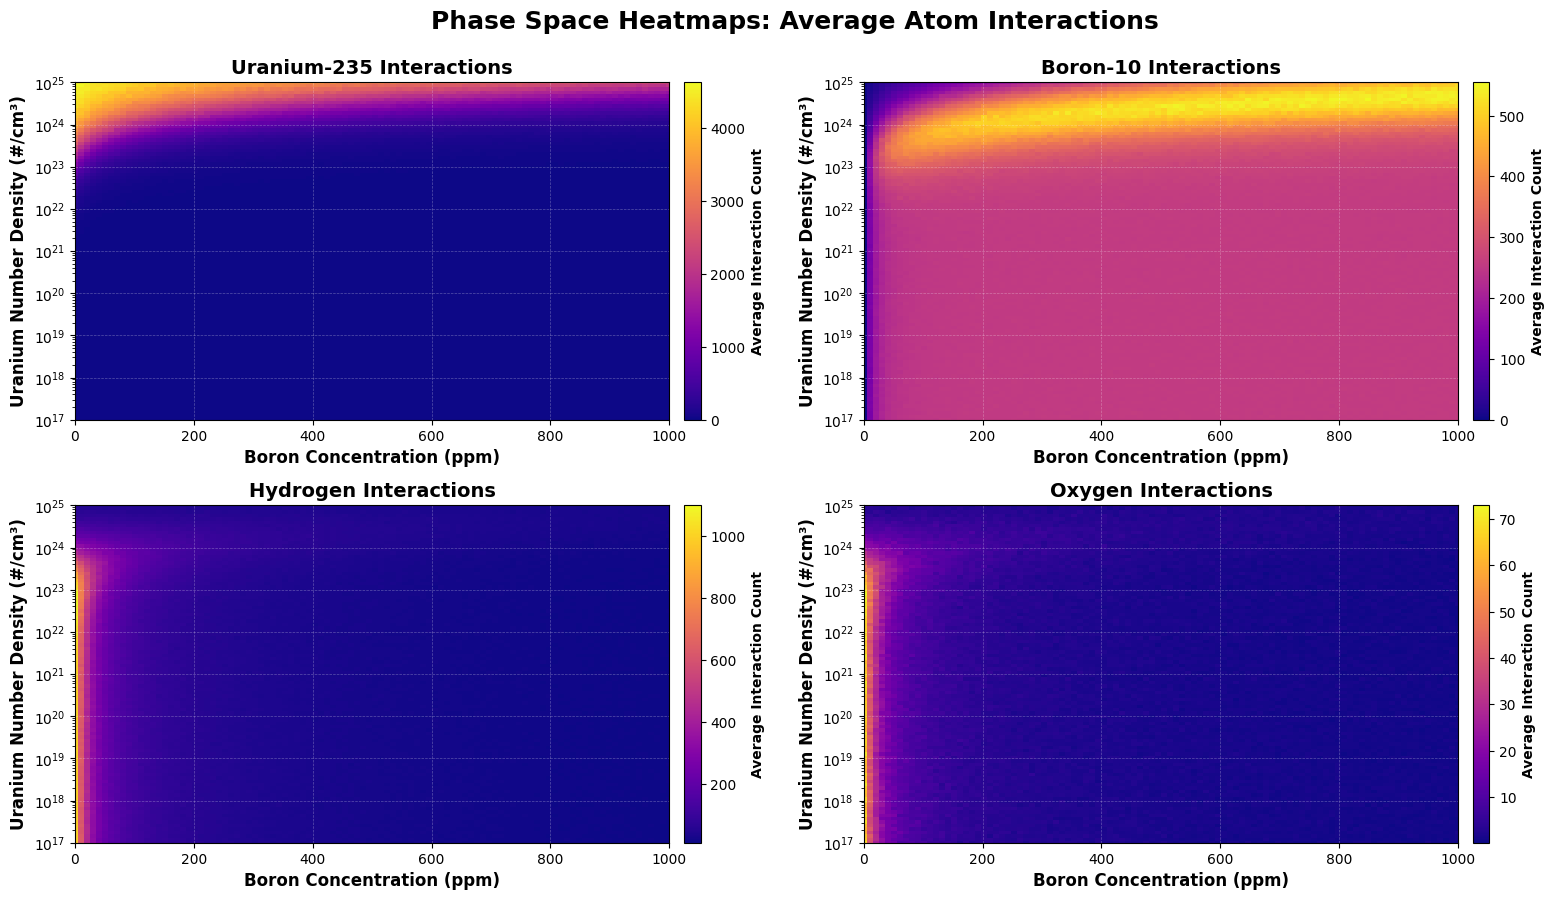

Results saved to 'atom_interactions_phase_space.npz'


In [25]:
# Run the phase space scan for interactions
print("\n" + "="*70)
input("Press Enter to start atom interaction phase space scan...")

results_dict, boron_range, uranium_range = scan_phase_space_2d_interactions(
    boron_space=100, 
    uranium_space=100,
    replications=10
)

# Plot the four heatmaps
fig = plot_interaction_heatmaps(results_dict, boron_range, uranium_range)

# Optionally save results
print("Results saved to 'atom_interactions_phase_space.npz'")

#### Image for Interaction Species Count Phase Space  (In Case Code Doesn't Run in Time)


![Interaction](https://i.imgur.com/ParhSUl.png)

**Figure 13**. Quantitative 2-D phase spaces of the number of atom interactions for uranium, boron, hydrogen, and oxygen.

#### Interaction of Species Phase Space Analysis 

**Uranium**  

* **Effect of number density**: We see that when U-235 has a number density that is less than $10e23/cm^3$, the number of interactions skyrockets down to zero. This is what we saw in Part I 
* **Effect of boron concentration**: As boron concentration increases, we see that the width of higher average interaction counts decreases (the wifth of the yellow/pink gradient line becomes thinner). This shows how the increase of boric acid concentration decreases the number of interactions with uranium. 

**Boron**
* We see an inverted effect on boron compared to uranium: Boron-10 interactions: the number of boron interactions is very lettile when boron concentration is little. Interestingly though, we also see that the number of boron-10 interactions is highest when uranium number density is high. This is not what we expect, given that a high uranium number density should entail that most neutrons are captured by uranium atoms. **Why might this be the case**? 
* It is possible that this unexpected pattern occurs due to the high number of neutrons created by uranium. When uranium denisty is high, more neutrons undergo fission, meaning more neutrons are created. This leaves more proabilities for atoms to collide with boron. This explanation is in line with our graphs; while more interactions for boron happen when uranium number density is higher, the counts of boron is nevertheless still an entire magnitude less than that of uranium 
* It is possible that this does not happen for hydrogen and oxygen because their macroscopic cross sections are just so low that the effect on hydrogen and oxygen as not as substantial as that of boron

**Hydrogen & Oxygen**
* For both oxygen and hydrogen, we see a bright line of interactions when boron concentration is very low and uranium number density is less than $10e24/cm^3$. However, even with a slight uranium and boron increase, oxygen's and hydrogen's interactions are immediately overpowered due to their small macroscopic cross sections.

# Results & Discussion

## Part I General Analysis 

From Part I of our analysis, we come to the following main conclusions: 

* **Multiplication Factor**: The multiplication factor $k$ is roughly proportional by the inverse square root of boron acidity concentration, and that it is roughly proportional by the square root of uranium number density. 
* **Interacted species distribution with Boric Acid**: As boric acid concentration increases, the number of interacations with uranium, hydrogen, and oxygen decrease, with the number of each species collisions proportional to their respective macroscopic cross sections. 
* **Interacted species distribution with Uranium Number Density**: As uranium number density increases, the number of interations with hydrogen, boron, and oxygen decrease. At roughly number density of roughly 10e25, nearly all collisions are uranium-based, meaning that no interactions are contributed from the other three atoms.  

## Part II General Analysis 

**Multiplication Factor Phase Space** 

* **General**: Similar to Part I of our analysis, multiplication factor decreases in a diagonal from top left to bottom right in our phase space, as uranium decreases and boric acid concentration increases. 
* **Multiplication Factor of 1**: The combinations of uranium number density and boric acid concentration that yield a multiplcaton factor of $k=1 ± 0.01$ trace a square root relationship 

**Interaction of Species Phase Space**
* **Uranium**: when U-235 number density is less than $10e23/cm^3$, the number of interactions is 0. As boron concentration increases, there is an decrease in interactions 
* **Boron**: Boron interactions are lowest at low boric acid concentrations. However, the boron-10 interactions are highest when uranium number density is highest; this is becasue more neutrons are created from uranium fission at high number densiries, allowing more neutrons to collide with boron.
* **Hydrogen & Oxygen**: There are hydrogen & oxygen interactions when boron concentration is extremely low and uranium number density is than $10e24/cm^3$. Outside this domain, there are very minimal (or even zero) interactions with the two species.


## Limitations & Next Steps 

### Technical Limitations  
* **Machine Precision**: Since we created phase space diagrams based on a number of discretized parameters of boric acid concentration and uranium number density, we cannot ever make a true "continuous" heat map, no matter how small are intervals are. This means that there will be a slight lack in machine precision for our calculations and simulations, affecting the overall results of our project
* **CPU Memory & Simplistic Model**: Due to the CPU's limited memory, the code used in this simulation had to be simplified so that it can compile within a reasonable amount of time. For this reason, the number of starting neutrons was very low, even though this number is nowhere near what is in realistic scenarios. Furthermore, the number of generations in this simulation had to be restricted, which may affect our overall understanding of the effects of our two parameters on the chain reaction. 

### Next Steps 
* **Fitting functions to longitudinal graphs**: In Part I of analysis, I show how increasing broon concentration and uranium number density seem to correspond to an inverse square root and a logarithmic relationship, respectively. Actually fitting such functions to my graphs and determining relevant statistics such as chi-squared values would make this analysis more quantitative and thorough.
* **Improving Phase Space Resolution**: In our Part II analysis, we see that our phase space resolution is very low. Running the phase space over more combinations would increase the resolution of the graph and allow us to gain a better understanding of how multiplication factor and the count of each species behave.  
* **Fitting equations to graphs**: In this project, I often use terminology such as "inverse square-root like" or "square-root like" to express the shape that the graph takes. However, this language is quite imprecise. The validity of our results would be increased if fitted our data to actual equations, generating validation measures such as chi squared and residual plots.
* **Incorporating More Processes**: In our simulation, we assume that the byproducts produced in our chemical reactions to not affect the system. However, this is far from true! Adding in the reactions that occur after our primary reactions would be a good step to increasing the complexity of the project.
* **Incorporating Other Factors Influenced by Phase Space**: In this project, we only explore the multiplication factor and the count of each species' interactison over five generations. However, ther are many other factors that we can look into! For example, how much heat is produced in this process, and how does that influence our system? Incorporating factors such as energy creation and heat would help make our simulation more realistic and interesting. 

## Acknowledgements

* I acknowledge the help of Sumaiya Hussain and Sam Quastel for providing my with initial feedback on my first draft of my project. 
* I acknowledge the help of one of that PHYS 210 TAs, Russell, for providing feedback for my simulation code for the function run_simulation_once().
* I acknowledge the help of Claude AI for making the plots for mt data and 2-dimensional phase spaces.

## References

[1] https://en.wikipedia.org/wiki/Nuclear_fission

[2] https://uidaho.pressbooks.pub/nuclearengineering/chapter/nuclear-reactor-physics/

[3] https://www.energy.gov/ne/articles/uranium-enrichment-explained#:~:text=Uranium%20Enrichment%20Levels&text=Low%20Enriched%20Uranium%20%28LEU%29%20is,and%205%20percent%20U%2D235 

[4] https://www.chemlin.org/isotope/boron-10 

[5] https://www.nuclear-power.com/nuclear-power/reactor-physics/nuclear-engineering-fundamentals/neutron-nuclear-reactions/microscopic-cross-section/

[6] https://www.nuclear-power.com/nuclear-power/reactor-physics/nuclear-engineering-fundamentals/neutron-nuclear-reactions/microscopic-cross-section/ 

[7] https://en.wikipedia.org/wiki/Maxwell%E2%80%93Boltzmann_distribution

[8] https://wwwndc.jaea.go.jp/cgi-bin/Tab80WWW.cgi?lib=J40&iso=B010

[9] https://en.wikipedia.org/wiki/Nuclear_cross_section 

[10] https://www.nuclear-power.com/nuclear-power/reactor-physics/nuclear-engineering-fundamentals/neutron-nuclear-reactions/macroscopic-cross-section/  

[11] https://docs.openmc.org/en/v0.12.1/methods/neutron_physics.html#:~:text=As%20a%20particle%20travels%20through,to%20a%20cumulative%20distribution%20function

[12] https://world-nuclear.org/information-library/nuclear-fuel-cycle/nuclear-power-reactors/nuclear-power-reactors 

[13] https://www.nuclear-power.com/nuclear-power/reactor-physics/neutron-diffusion-theory/neutron-leakage/

[14] https://en.wikipedia.org/wiki/Nuclear_reactor_coolant

[15] https://world-nuclear.org/information-library/nuclear-fuel-cycle/introduction/physics-of-nuclear-energy 

[16] https://wwwndc.jaea.go.jp/cgi-bin/Tab80WWW.cgi?lib=J40&iso=U235

[17] https://wwwndc.jaea.go.jp/cgi-bin/Tab80WWW.cgi?lib=J40&iso=H001

[18] https://wwwndc.jaea.go.jp/cgi-bin/Tab80WWW.cgi?lib=J40&iso=O016

[19] https://www.nuclear-power.com/nuclear-power/reactor-physics/neutron-diffusion-theory/diffusion-coefficient/



## Appendix 1: Code validation

### A1.1: Initial Validation for run_simulation_once() 

We first check that run_simulation_once() executes results as we expect. To do this, we set both boric acid concentration and uranium number density to be 0. 


 
==================TOTAL MACROSCOPIC CROSS SECTIONS OF EACH SPECIES===================
 
* Uranium-235:       0
* Boron-10:          0
* Hydrogen:          2
* Oxygen:         0.13 

 THE STARTING MEAN FREE PATH IS  4.59e-01 cm 

================= SIMULATION RESULTS ================ 

 Gen 0 to 1 || k : 0.935 || std: 0.01 

 Gen 1 to 2 || k : 0.944 || std: 0.02 

 Gen 2 to 3 || k : 0.952 || std: 0.01 

 Gen 3 to 4 || k : 0.958 || std: 0.01 

 Gen 4 to 5 || k : 0.960 || std: 0.01 

AVERAGE k VALUE ACROSS ALL GENERATIONS:  0.950 || std:  0.009 

================= SIMULATION COMPLETE ================= 



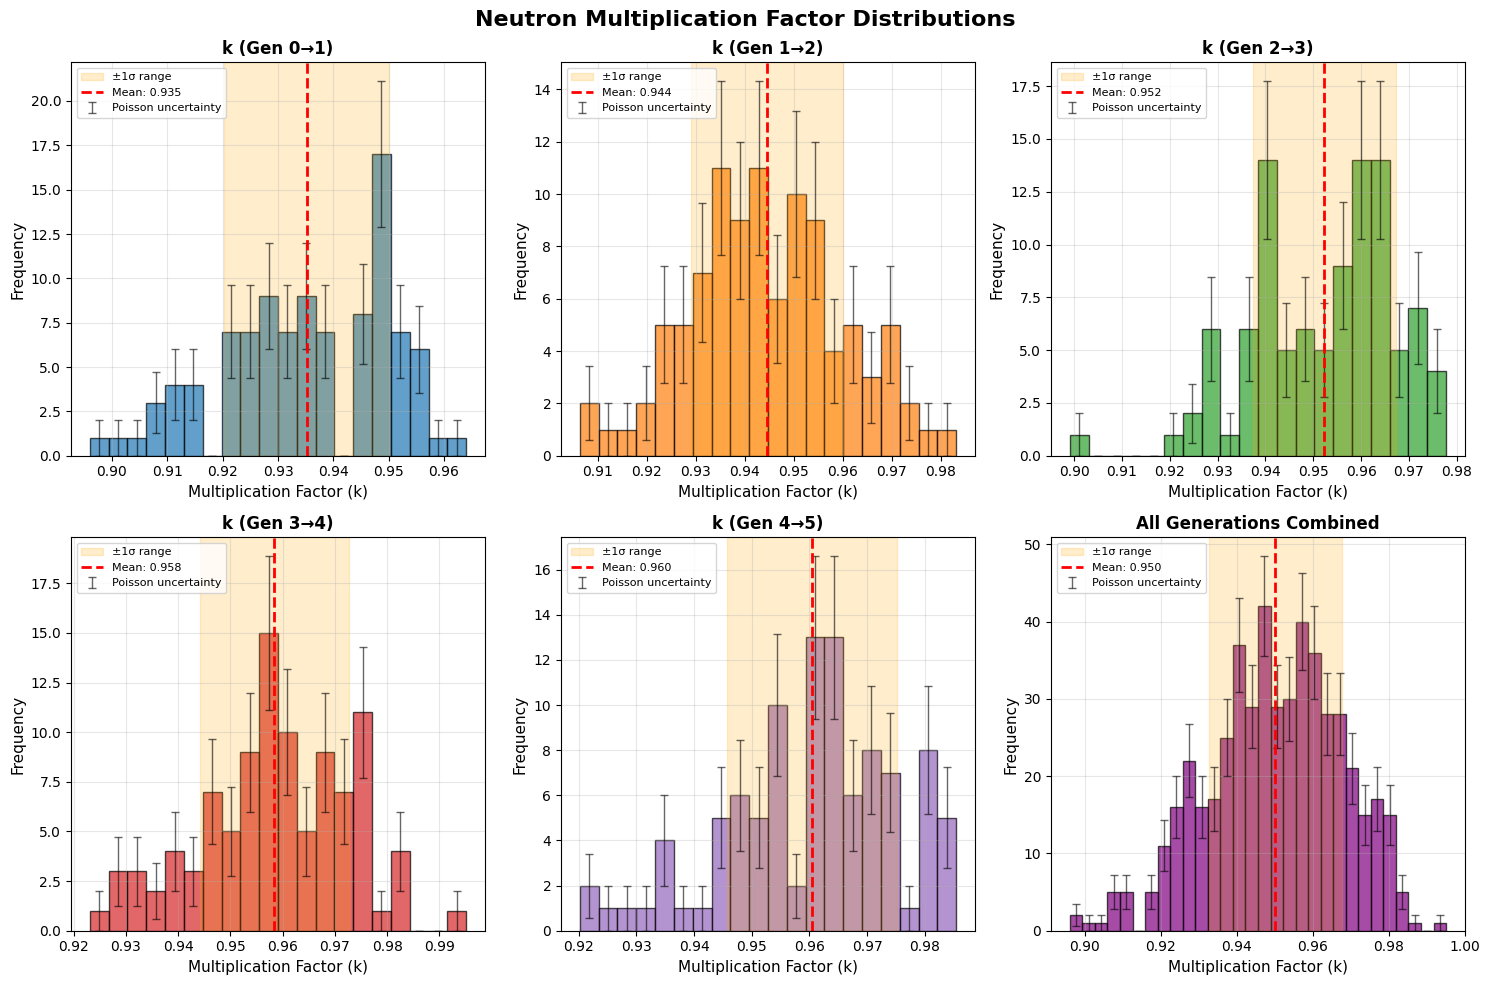


HISTOGRAM SUMMARY STATISTICS

All k values combined:
  Mean: 0.950
  Std:  0.018
  Min:  0.896
  Max:  0.995
  Median: 0.952


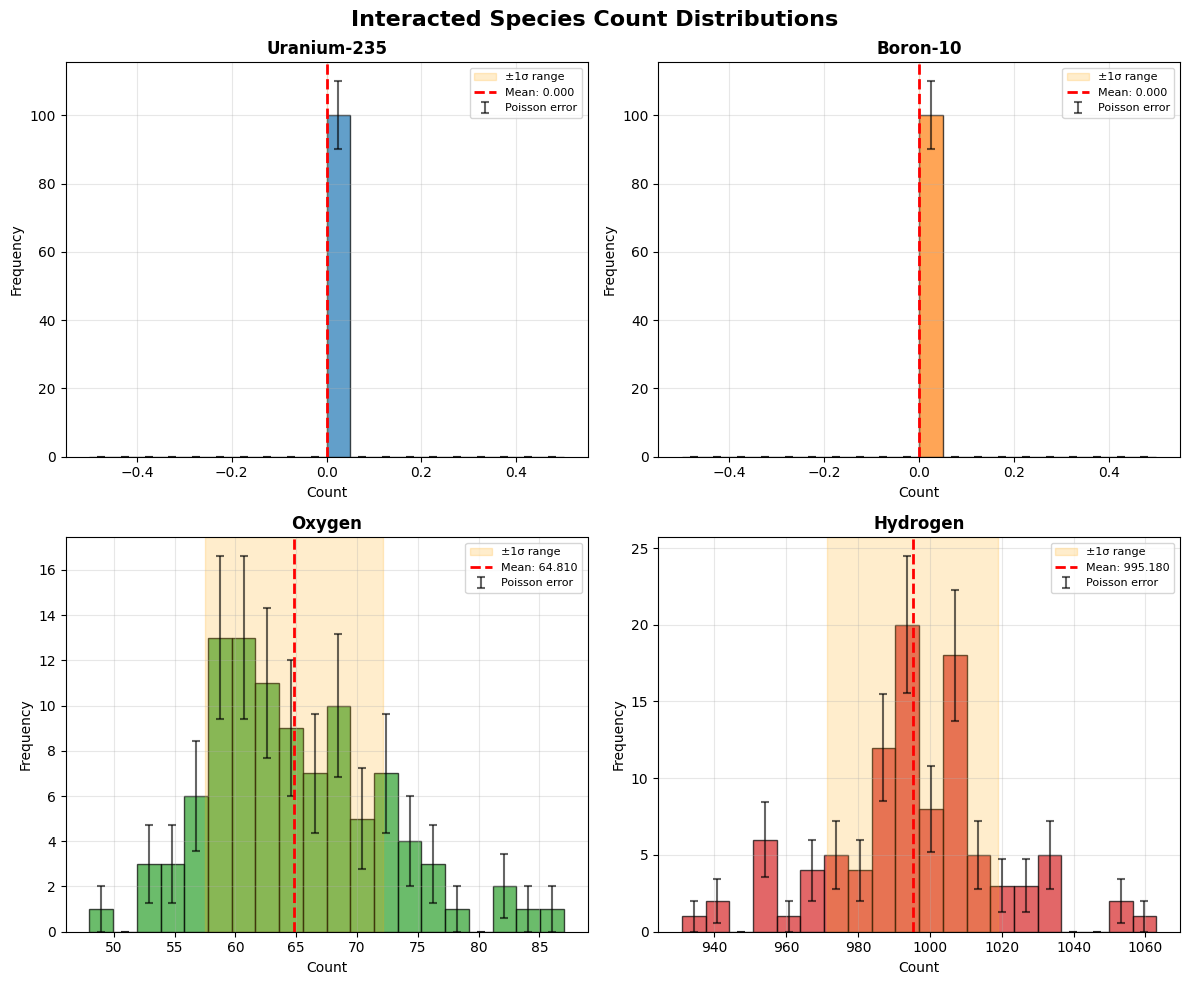


CONSUMED SPECIES SUMMARY STATISTICS

* Uranium-235: 0 || std:  0 
* Boron-10: 0 || std:  0 
* Oxygen: 64 || std:  7.3 
* Hydrogen: 995 || std:  24 



In [30]:

unumberdensity = 0
boronconc = 0
k1, k2, k3, k4, k5, means, stds, ucount,ocount,bcount,hcount,means1, stds1, mean_free_paths = run_simulation_multiple(boronconc,unumberdensity,100)

plot_histograms(k1, k2, k3, k4, k5, means, stds, "No")

plot_histograms_count(ucount,ocount,bcount,hcount,means1, stds1) 

We see that the graphs output exactly what we expect to happen; the first plot shows that the multiplication factor is subcritical due to the fact that there shouldn't be any fissions occurring in the experiment. Furthermore, in the interacted species count distribution plot, we see that indeed, there are no uranium or boron interactions. All interactions are with oxygen and hydrogen absorption, and the number of each of their interactions is roughly proportional to their macroscopic cross sections. We also see that the multiplication factor, although subcritical is close to one; this is due to the fact that all neutrons get scatterd by hydrogen, meaning that nearly all neutrons "survive". The onnly neutrons that disappear from the system are due to leakage.

### A1.2: Mean Free Path 

The second thing we check for our code validation process is the mean free path for each of our trials. In our code, we see that we are constantly updating the mean free path, due to the consumption of each of the four species in our simulation. However, given that the proportion of consumed species is magnitudes smaller than the total original number of uranium, boron, hydrogen, and oxygen, we expect that the mean free path should essentially stay the same. We test this using our function run_simulation_once().

In [27]:
k01,k12,k23, k34, k45, ucount, bcount, ocount, hcount, mean_free_paths = run_simulation_once(10,10e23,"No")
print(f"The mean free paths are {mean_free_paths}") 

The mean free paths are [0.042401175313366075, 0.042401175313366075, 0.042401175313366075, 0.042401175313366075, 0.042401175313366075, 0.042401175313366075, 0.042401175313366075, 0.042401175313366075, 0.042401175313366075, 0.042401175313366075, 0.042401175313366075, 0.042401175313366075, 0.042401175313366075, 0.042401175313366075, 0.042401175313366075, 0.042401175313366075, 0.042401175313366075, 0.042401175313366075, 0.042401175313366075, 0.042401175313366075, 0.042401175313366075, 0.042401175313366075, 0.042401175313366075, 0.042401175313366075, 0.042401175313366075, 0.042401175313366075, 0.042401175313366075, 0.042401175313366075, 0.042401175313366075, 0.042401175313366075, 0.042401175313366075, 0.042401175313366075, 0.042401175313366075, 0.042401175313366075, 0.042401175313366075, 0.042401175313366075, 0.042401175313366075, 0.042401175313366075, 0.042401175313366075, 0.042401175313366075, 0.042401175313366075, 0.042401175313366075, 0.042401175313366075, 0.042401175313366075, 0.04240

We see that this is indeed the case: across all iterations, the mean free path does not change.